# 02. Stationarity Diagnostics for Thailand
This notebook performs unit root and stationarity diagnostics (ADF, KPSS, PP) for the SVAR variables of Thailand. 

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
import warnings

# Visualization
plt.rcParams['figure.dpi'] = 300
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

## 1. Load data

In [39]:
# Load model-ready data
df = pd.read_csv("../../data/processed/THA_model_ready.csv", parse_dates=['date'], index_col='date')
print("Loaded THA_model_ready.csv")

print("Data Overview:")
print(f"Shape (rows, columns): {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Loaded THA_model_ready.csv
Data Overview:
Shape (rows, columns): (217, 5)

Data Types:
ln_WTI      float64
ln_GDP      float64
ln_CPI      float64
Interest    float64
ln_FX       float64
dtype: object

Missing Values:
ln_WTI      0
ln_GDP      0
ln_CPI      0
Interest    0
ln_FX       0
dtype: int64


## 2.  Unit Root Test Functions

In [40]:
def perform_adf_test(series, variable_name, regression='c'):
    """
    Perform Augmented Dickey-Fuller test
    H0: Unit root exists (non-stationary)
    H1: No unit root (stationary)
    Reject H0 if p-value < 0.05
    """
    try:
        s = series.dropna()
        result = adfuller(
            s,
            autolag='AIC',
            regression=regression
        )
        return {
            'Variable': variable_name,
            'Regression': regression,
            'Test Statistic': result[0],
            'P-Value': result[1],
            'Lags Used': result[2],
            'Observations': result[3],
            'Critical (1%)': result[4]['1%'],
            'Critical (5%)': result[4]['5%'],
            'Critical (10%)': result[4]['10%']
        }
    except Exception as e:
        print(f"ADF test failed for {variable_name} ({regression}): {str(e)}")
        return None

def perform_pp_test(series, variable_name, regression='c'):
    """
    Perform Phillips-Perron test using arch.unitroot
    H0: Unit root exists (non-stationary)
    H1: No unit root (stationary)
    Reject H0 if p-value < 0.05
    """
    try:
        s = series.dropna()
        trend = 'c' if regression == 'c' else 'ct'
        pp = PhillipsPerron(s, trend=trend)
        return {
            'Variable': variable_name,
            'Regression': regression,
            'Test Statistic': pp.stat,
            'P-Value': pp.pvalue
        }
    except Exception as e:
        print(f"PP test failed for {variable_name} ({regression}): {str(e)}")
        return None

print("Unit root test functions (ADF, PP) defined")

Unit root test functions (ADF, PP) defined


## 3. Regression Specification

- `ct` (constant + trend) is used for GDP, CPI, and Interest because these macroeconomic variables often exhibit deterministic trends over time.
- `c` (constant only) is used for WTI and FX, as these series are not expected to have a deterministic trend in the current economic specification.

This choice ensures the unit root tests are aligned with the economic characteristics of each variable.

In [41]:
regression_map_level = {
    'ln_WTI': 'c',
    'ln_GDP': 'ct',
    'ln_CPI': 'ct',
    'Interest': 'ct',
    'ln_FX': 'c'
}

regression_map_diff = {col: 'c' for col in df.columns}

print("ADF specification at level:")
for k, v in regression_map_level.items():
    print(f"{k:10} -> {v}")

ADF specification at level:
ln_WTI     -> c
ln_GDP     -> ct
ln_CPI     -> ct
Interest   -> ct
ln_FX      -> c


## 4. First-Difference Diagnostics

In [42]:
# Create differenced dataset
df_diff = df.diff().dropna()

print(f"Differenced dataset shape: {df_diff.shape}")
print(f"First 5 rows of differenced data:\n{df_diff.head()}\n")

# Run ADF tests on first differences
adf_diff_results = []
for col in df_diff.columns:
    reg = regression_map_diff.get(col, 'c')
    result = perform_adf_test(df_diff[col], f'Δ{col}', regression=reg)
    if result:
        adf_diff_results.append(result)

adf_diff_df = pd.DataFrame(adf_diff_results)

print("ADF Test Results on First Differences:")
print(adf_diff_df[['Variable', 'Regression', 'Test Statistic', 'P-Value', 'Critical (5%)']].to_string(index=False))

Differenced dataset shape: (216, 5)
First 5 rows of differenced data:
              ln_WTI   ln_GDP   ln_CPI  Interest     ln_FX
date                                                      
2006-02-01 -0.060655 0.015358 0.001866 -0.018937 -0.007427
2006-03-01  0.016960 0.015126 0.001863 -0.018937 -0.007483
2006-04-01  0.102390 0.014900 0.001859 -0.018937 -0.007539
2006-05-01  0.019965 0.014681 0.001856 -0.018937 -0.007597
2006-06-01  0.001507 0.014469 0.001852 -0.018937 -0.007655

ADF Test Results on First Differences:
 Variable Regression  Test Statistic  P-Value  Critical (5%)
  Δln_WTI          c       -9.812113 0.000000      -2.875143
  Δln_GDP          c       -2.526133 0.109245      -2.875885
  Δln_CPI          c       -1.858184 0.351981      -2.875885
ΔInterest          c       -2.800224 0.058242      -2.875079
   Δln_FX          c       -2.785121 0.060431      -2.875079


## 5. Preliminary Stationarity Summary

In [43]:
# Level and diff1 tests + Preliminary Summary 
def perform_kpss_test(series, regression='c'):
    try:
        statistic, p_value, lags, crit = kpss(series.dropna(), regression=regression, nlags='auto')
        return {
            'Test Statistic': statistic,
            'P-Value': p_value,
            'Lags Used': lags,
            'Critical (5%)': crit['5%']
        }
    except Exception as e:
        print(f"KPSS test failed: {str(e)}")
        return None

# Run all tests at level and diff1 for all variables, all specs
adf_level_c, adf_level_ct, kpss_level_c, kpss_level_ct = [], [], [], []
pp_level_c, pp_level_ct = [], []
adf_diff_c, kpss_diff_c, pp_diff_c = [], [], []

for col in df.columns:
    # ADF at level: c and ct
    adf_c = perform_adf_test(df[col], col, regression='c')
    adf_ct = perform_adf_test(df[col], col, regression='ct')
    if adf_c: adf_level_c.append(adf_c)
    if adf_ct: adf_level_ct.append(adf_ct)
    # KPSS at level: c and ct
    kpss_c = perform_kpss_test(df[col], regression='c')
    kpss_ct = perform_kpss_test(df[col], regression='ct')
    if kpss_c: kpss_level_c.append({'Variable': col, **kpss_c})
    if kpss_ct: kpss_level_ct.append({'Variable': col, **kpss_ct})
    # PP at level: c and ct
    pp_c = perform_pp_test(df[col], col, regression='c')
    pp_ct = perform_pp_test(df[col], col, regression='ct')
    if pp_c: pp_level_c.append(pp_c)
    if pp_ct: pp_level_ct.append(pp_ct)

# First differences
df_diff = df.diff().dropna()
for col in df_diff.columns:
    adf_d = perform_adf_test(df_diff[col], f'Δ{col}', regression='c')
    if adf_d: adf_diff_c.append(adf_d)
    kpss_d = perform_kpss_test(df_diff[col], regression='c')  # always use 'c' for diff1
    if kpss_d: kpss_diff_c.append({'Variable': col, **kpss_d})
    pp_d = perform_pp_test(df_diff[col], f'Δ{col}', regression='c')
    if pp_d: pp_diff_c.append(pp_d)

# Convert to DataFrames
adf_level_c_df = pd.DataFrame(adf_level_c)
adf_level_ct_df = pd.DataFrame(adf_level_ct)
kpss_level_c_df = pd.DataFrame(kpss_level_c)
kpss_level_ct_df = pd.DataFrame(kpss_level_ct)
pp_level_c_df = pd.DataFrame(pp_level_c)
pp_level_ct_df = pd.DataFrame(pp_level_ct)
adf_diff_c_df = pd.DataFrame(adf_diff_c)
kpss_diff_c_df = pd.DataFrame(kpss_diff_c)
pp_diff_c_df = pd.DataFrame(pp_diff_c)

# Classification logic (strict, as requested)
summary = []
for col in df.columns:
    # ADF
    adf_c_p = adf_level_c_df[adf_level_c_df['Variable'] == col]['P-Value'].values[0]
    adf_ct_p = adf_level_ct_df[adf_level_ct_df['Variable'] == col]['P-Value'].values[0]
    # KPSS
    kpss_c_p = kpss_level_c_df[kpss_level_c_df['Variable'] == col]['P-Value'].values[0]
    kpss_ct_p = kpss_level_ct_df[kpss_level_ct_df['Variable'] == col]['P-Value'].values[0]
    # PP
    pp_c_p = pp_level_c_df[pp_level_c_df['Variable'] == col]['P-Value'].values[0]
    pp_ct_p = pp_level_ct_df[pp_level_ct_df['Variable'] == col]['P-Value'].values[0]
    # First diff
    adf_diff_p = adf_diff_c_df[adf_diff_c_df['Variable'] == f'Δ{col}']['P-Value'].values[0]
    kpss_diff_p = kpss_diff_c_df[kpss_diff_c_df['Variable'] == col]['P-Value'].values[0]
    pp_diff_p = pp_diff_c_df[pp_diff_c_df['Variable'] == f'Δ{col}']['P-Value'].values[0]

    # Strict logic
    level_stationary = (adf_c_p < 0.05) and (kpss_c_p > 0.05)
    level_nonstationary = (adf_c_p >= 0.05) and (kpss_c_p < 0.05)
    diff1_stationary = (adf_diff_p < 0.05) and (kpss_diff_p > 0.05)

    if level_stationary:
        order = 'I(0)'
        reason = f"Level: ADF (c) p={adf_c_p:.3f} < 0.05 and KPSS (c) p={kpss_c_p:.3f} > 0.05"
    elif level_nonstationary and diff1_stationary:
        order = 'I(1)'
        reason = f"Level: ADF (c) p={adf_c_p:.3f} >= 0.05, KPSS (c) p={kpss_c_p:.3f} < 0.05; Diff1: ADF (c) p={adf_diff_p:.3f} < 0.05, KPSS (c) p={kpss_diff_p:.3f} > 0.05"
    else:
        order = 'Unresolved'
        reason = (f"Level: ADF (c) p={adf_c_p:.3f}, KPSS (c) p={kpss_c_p:.3f}; "
                  f"ADF (ct) p={adf_ct_p:.3f}, KPSS (ct) p={kpss_ct_p:.3f}; "
                  f"PP (c) p={pp_c_p:.3f}, PP (ct) p={pp_ct_p:.3f}; "
                  f"Diff1: ADF (c) p={adf_diff_p:.3f}, KPSS (c) p={kpss_diff_p:.3f}, PP (c) p={pp_diff_p:.3f}")
    summary.append({
        'Variable': col,
        'ADF_Level_p': adf_c_p,
        'ADF (ct)': adf_ct_p,
        'KPSS_Level_p': kpss_c_p,
        'KPSS (ct)': kpss_ct_p,
        'PP (c)': pp_c_p,
        'PP (ct)': pp_ct_p,
        'ADF_Diff1_p': adf_diff_p,
        'KPSS_Diff1_p': kpss_diff_p,
        'Diff1 PP (c)': pp_diff_p,
        'Order': order,
        'Reason': reason
    })

summary_df = pd.DataFrame(summary)
print('Preliminary summary:')
print(summary_df[['Variable','ADF_Level_p','KPSS_Level_p','ADF_Diff1_p','KPSS_Diff1_p','Order']])

Preliminary summary:
   Variable  ADF_Level_p  KPSS_Level_p  ADF_Diff1_p  KPSS_Diff1_p       Order
0    ln_WTI     0.009694      0.090217     0.000000      0.100000        I(0)
1    ln_GDP     0.404549      0.010000     0.109245      0.017252  Unresolved
2    ln_CPI     0.967147      0.010000     0.351981      0.100000  Unresolved
3  Interest     0.156695      0.010000     0.058242      0.100000  Unresolved
4     ln_FX     0.056278      0.100000     0.060431      0.040382  Unresolved


## 6. Extended Diagnostics for Unresolved Variables

In [44]:
# Extended diagnostics for unresolved variables (Diff2) 
unresolved_vars = summary_df[summary_df['Order'] == 'Unresolved']['Variable'].tolist()
df_diff2 = df.diff().diff().dropna()

adf_diff2_c, kpss_diff2_c, pp_diff2_c = [], [], []
for col in unresolved_vars:
    adf_d2 = perform_adf_test(df_diff2[col], f'dd_{col}', regression='c')
    if adf_d2: adf_diff2_c.append(adf_d2)
    kpss_d2 = perform_kpss_test(df_diff2[col], regression='c')
    if kpss_d2: kpss_diff2_c.append({'Variable': col, **kpss_d2})
    pp_d2 = perform_pp_test(df_diff2[col], f'dd_{col}', regression='c')
    if pp_d2: pp_diff2_c.append(pp_d2)

adf_diff2_c_df = pd.DataFrame(adf_diff2_c)
kpss_diff2_c_df = pd.DataFrame(kpss_diff2_c)
pp_diff2_c_df = pd.DataFrame(pp_diff2_c)

# Update summary with diff2 results for unresolved variables
for col in unresolved_vars:
    adf_d2_p = adf_diff2_c_df[adf_diff2_c_df['Variable'] == f'dd_{col}']['P-Value'].values[0]
    kpss_d2_p = kpss_diff2_c_df[kpss_diff2_c_df['Variable'] == col]['P-Value'].values[0]
    pp_d2_p = pp_diff2_c_df[pp_diff2_c_df['Variable'] == f'dd_{col}']['P-Value'].values[0]
    idx = summary_df[summary_df['Variable'] == col].index[0]
    summary_df.loc[idx, 'ADF_Diff2_p'] = adf_d2_p
    summary_df.loc[idx, 'KPSS_Diff2_p'] = kpss_d2_p
    summary_df.loc[idx, 'PP_Diff2_p'] = pp_d2_p
    # Strict logic for I(2)
    if (adf_d2_p < 0.05) and (kpss_d2_p > 0.05):
        summary_df.loc[idx, 'Order'] = 'I(2)'
        summary_df.loc[idx, 'Reason'] += f"; Diff2: ADF (c) p={adf_d2_p:.3f} < 0.05, KPSS (c) p={kpss_d2_p:.3f} > 0.05"
    else:
        summary_df.loc[idx, 'Reason'] += f"; Diff2: ADF (c) p={adf_d2_p:.3f}, KPSS (c) p={kpss_d2_p:.3f}, PP (c) p={pp_d2_p:.3f}"

# Final clean summary for reporting
final_summary = summary_df[['Variable','ADF_Level_p','KPSS_Level_p','ADF_Diff1_p','KPSS_Diff1_p','ADF_Diff2_p','KPSS_Diff2_p','Order','Reason']].copy()
print('Final summary:')
print(final_summary)

# Save summary to CSV
final_summary.to_csv("../../outputs/THA/stationarity_summary_tha.csv", index=False)

Final summary:
   Variable  ADF_Level_p  KPSS_Level_p  ADF_Diff1_p  KPSS_Diff1_p  \
0    ln_WTI     0.009694      0.090217     0.000000      0.100000   
1    ln_GDP     0.404549      0.010000     0.109245      0.017252   
2    ln_CPI     0.967147      0.010000     0.351981      0.100000   
3  Interest     0.156695      0.010000     0.058242      0.100000   
4     ln_FX     0.056278      0.100000     0.060431      0.040382   

   ADF_Diff2_p  KPSS_Diff2_p Order  \
0          NaN           NaN  I(0)   
1     0.000000      0.100000  I(2)   
2     0.000000      0.100000  I(2)   
3     0.000000      0.100000  I(2)   
4     0.000000      0.100000  I(2)   

                                              Reason  
0  Level: ADF (c) p=0.010 < 0.05 and KPSS (c) p=0...  
1  Level: ADF (c) p=0.405, KPSS (c) p=0.010; ADF ...  
2  Level: ADF (c) p=0.967, KPSS (c) p=0.010; ADF ...  
3  Level: ADF (c) p=0.157, KPSS (c) p=0.010; ADF ...  
4  Level: ADF (c) p=0.056, KPSS (c) p=0.100; ADF ...  


## 7. Visual and Data Diagnostics

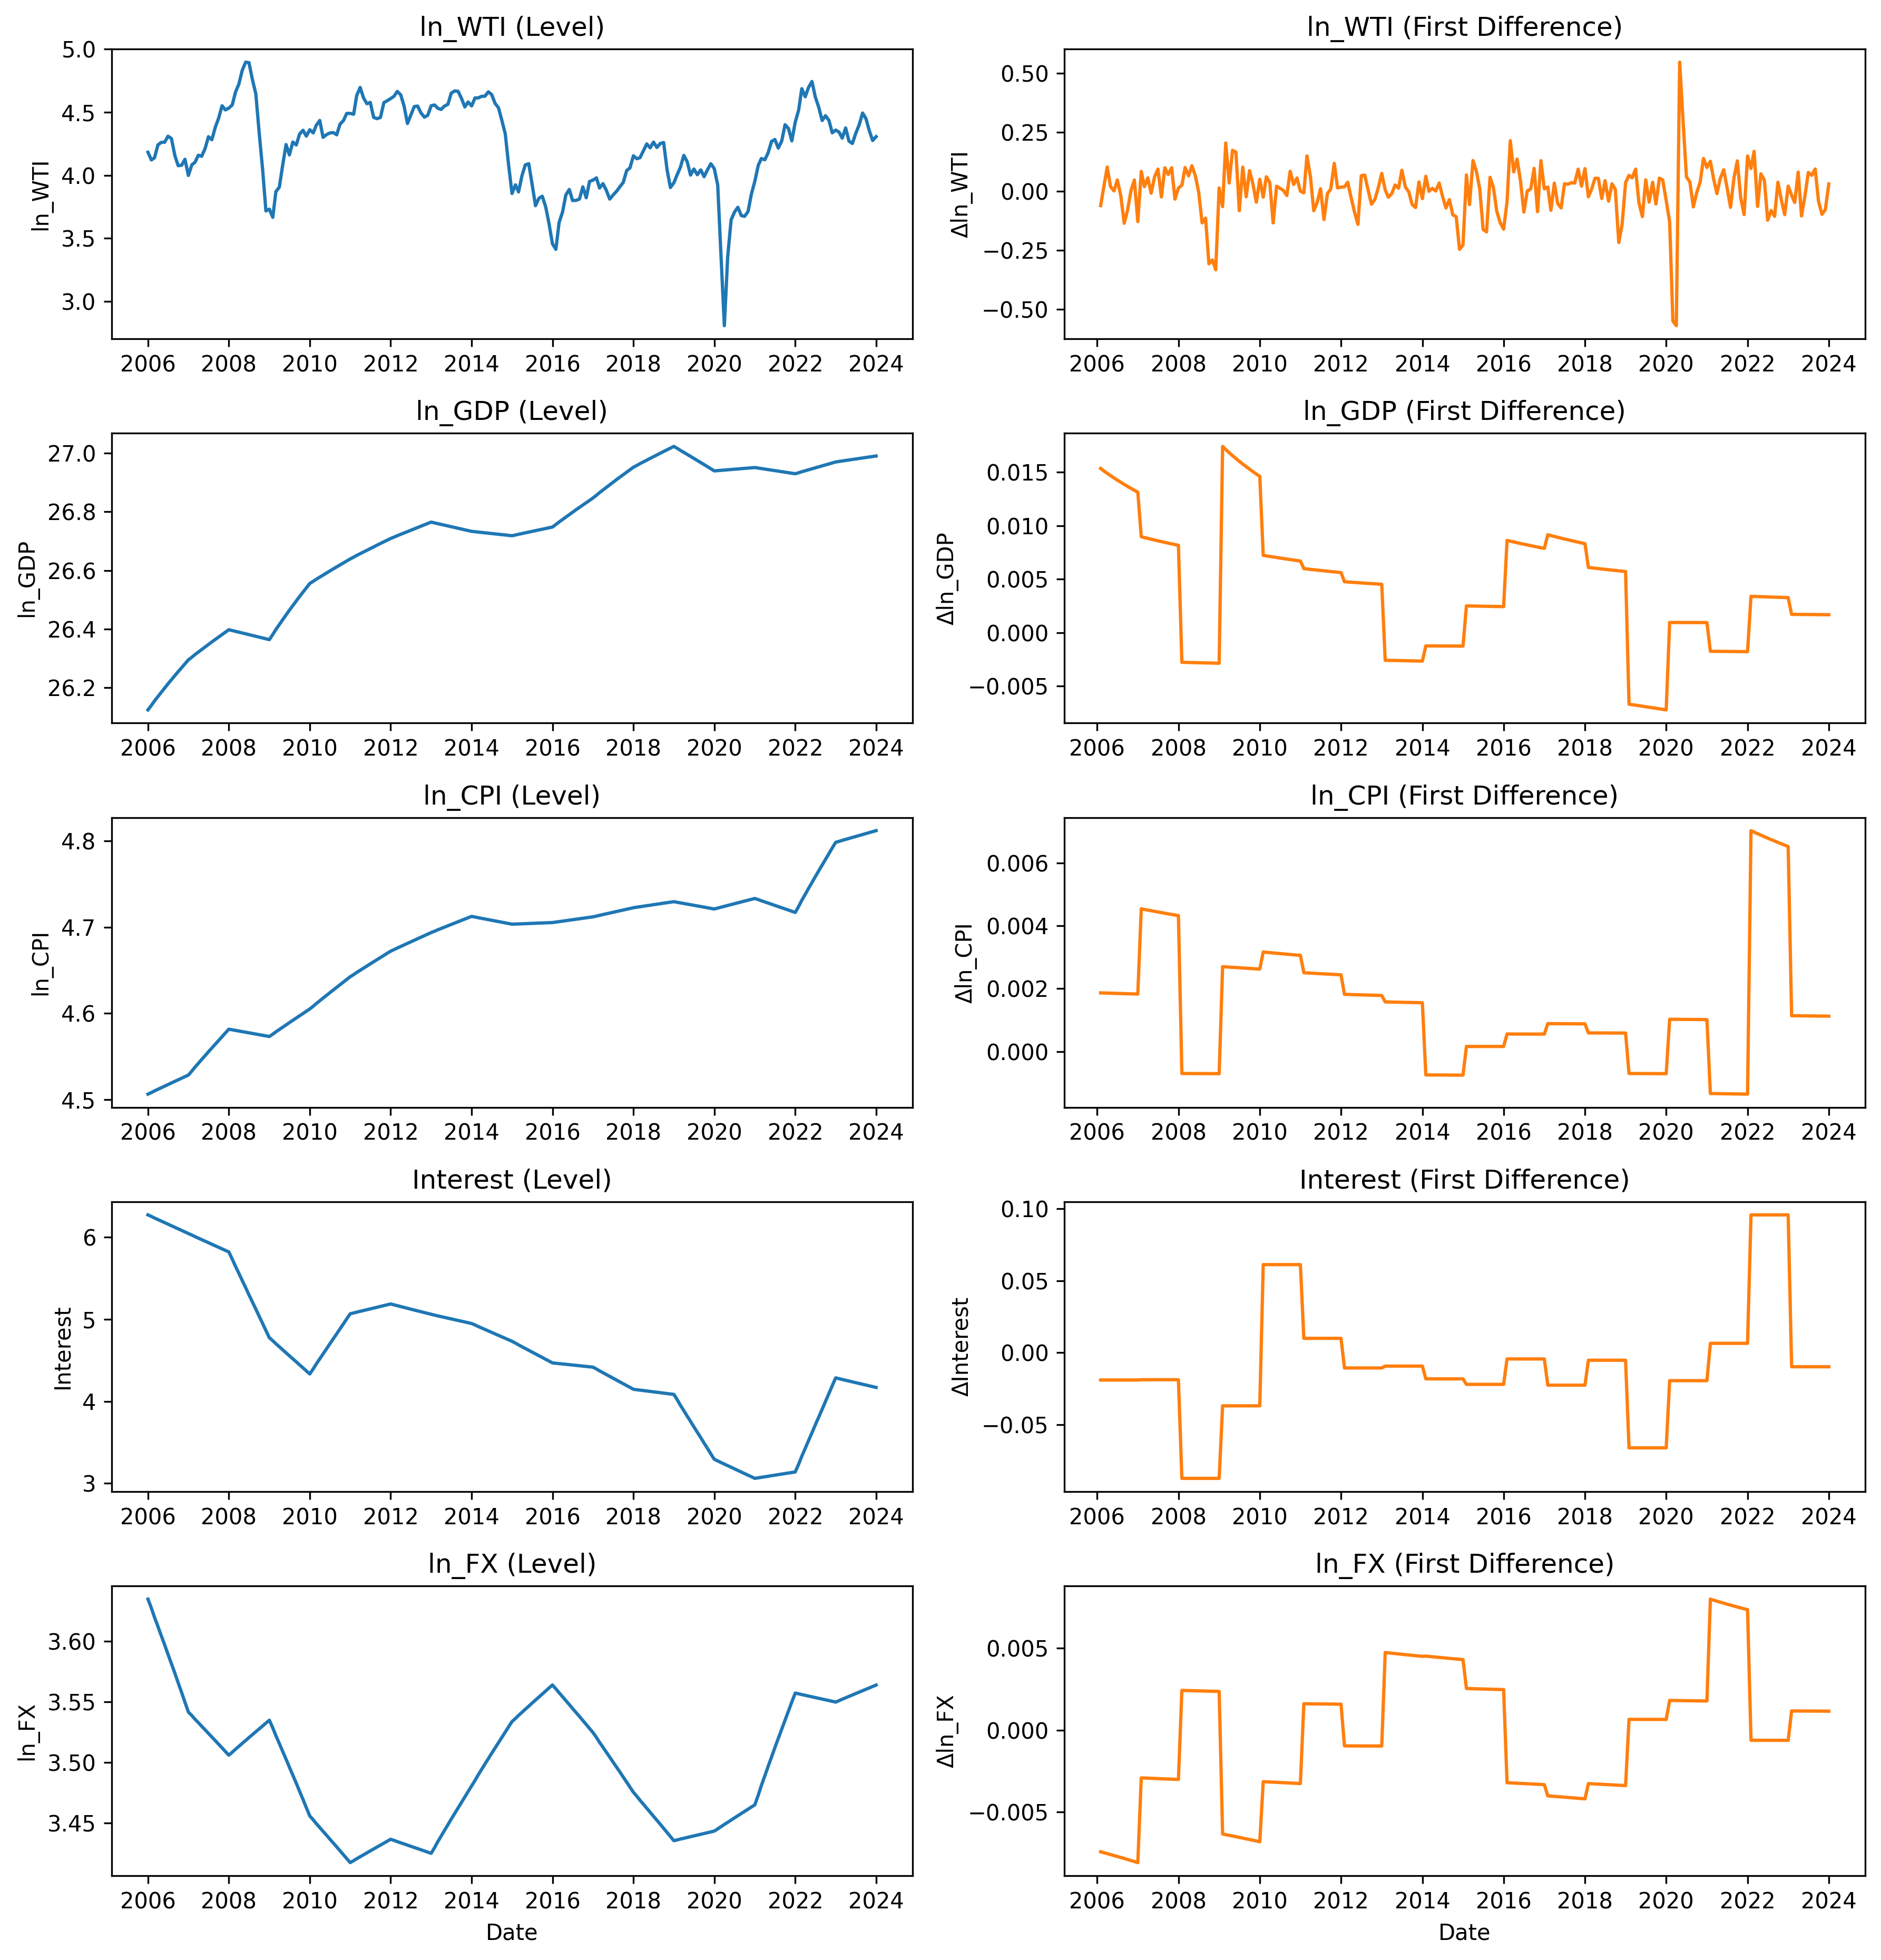

In [45]:
# Visual inspection: plot each variable at level and diff1 
fig, axes = plt.subplots(len(df.columns), 2, figsize=(12, 2.5*len(df.columns)))
for i, col in enumerate(df.columns):
    # Level
    axes[i,0].plot(df.index, df[col], color='tab:blue')
    axes[i,0].set_title(f'{col} (Level)')
    axes[i,0].set_ylabel(col)
    # Diff1
    axes[i,1].plot(df_diff.index, df_diff[col], color='tab:orange')
    axes[i,1].set_title(f'{col} (First Difference)')
    axes[i,1].set_ylabel(f'Δ{col}')
for j in range(2):
    axes[-1,j].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 8. Data Diagnostics: Interpolation and Smoothing Check

In [46]:
# Data diagnostics: check for interpolation/smoothing 
print("Data Diagnostics: Interpolation/Smoothing Check")
for col in df.columns:
    diff = df[col].diff().dropna()
    var_diff = diff.var()
    repeated = (diff == 0).sum()
    near_const = ((diff - diff.mean()).abs() < 1e-6).sum()
    print(f"{col}: Var(diff)={var_diff:.6f}, Repeated diffs={repeated}, Near-constant diffs={near_const}")
    print(diff.describe())

Data Diagnostics: Interpolation/Smoothing Check
ln_WTI: Var(diff)=0.012281, Repeated diffs=0, Near-constant diffs=0
count   216.000000
mean      0.000575
std       0.110819
min      -0.568191
25%      -0.047703
50%       0.014052
75%       0.059570
max       0.545852
Name: ln_WTI, dtype: float64
ln_GDP: Var(diff)=0.000034, Repeated diffs=0, Near-constant diffs=0
count   216.000000
mean      0.004003
std       0.005851
min      -0.007220
25%      -0.001245
50%       0.003963
75%       0.008176
max       0.017417
Name: ln_GDP, dtype: float64
ln_CPI: Var(diff)=0.000004, Repeated diffs=0, Near-constant diffs=0
count   216.000000
mean      0.001416
std       0.001960
min      -0.001363
25%       0.000157
50%       0.001074
75%       0.002474
max       0.007040
Name: ln_CPI, dtype: float64
Interest: Var(diff)=0.001527, Repeated diffs=0, Near-constant diffs=0
count   216.000000
mean     -0.009744
std       0.039076
min      -0.087158
25%      -0.021961
50%      -0.014340
75%      -0.004314
ma

## 9. Seasonality Diagnostics

Monthly macroeconomic data may contain seasonal patterns. Seasonality can cause a series to appear non-stationary even if the main issue is recurring seasonal structure rather than a higher-order unit root. Therefore, we want to test whether removing seasonality changes the stationarity conclusions.

## 10. Seasonal Pattern Inspection

### 10.1 Plot monthly series by variable

Below, we visually inspect each variable for recurring seasonal behavior.

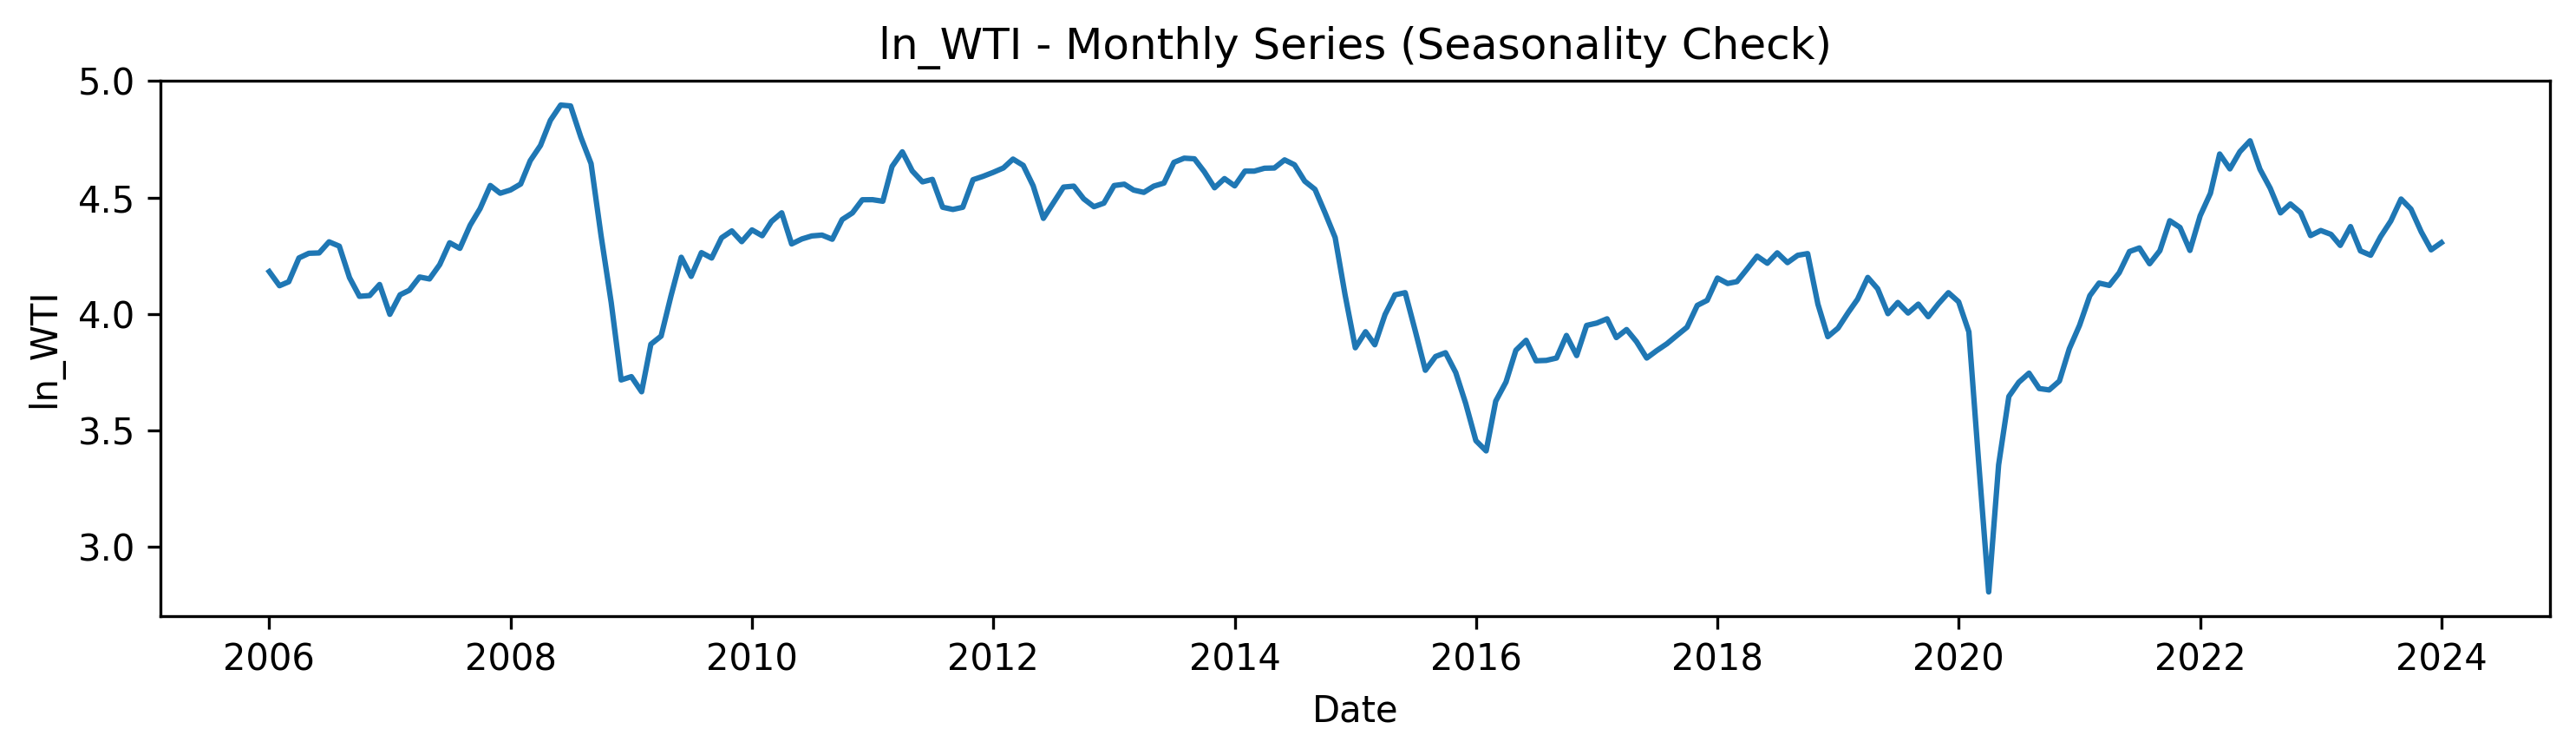

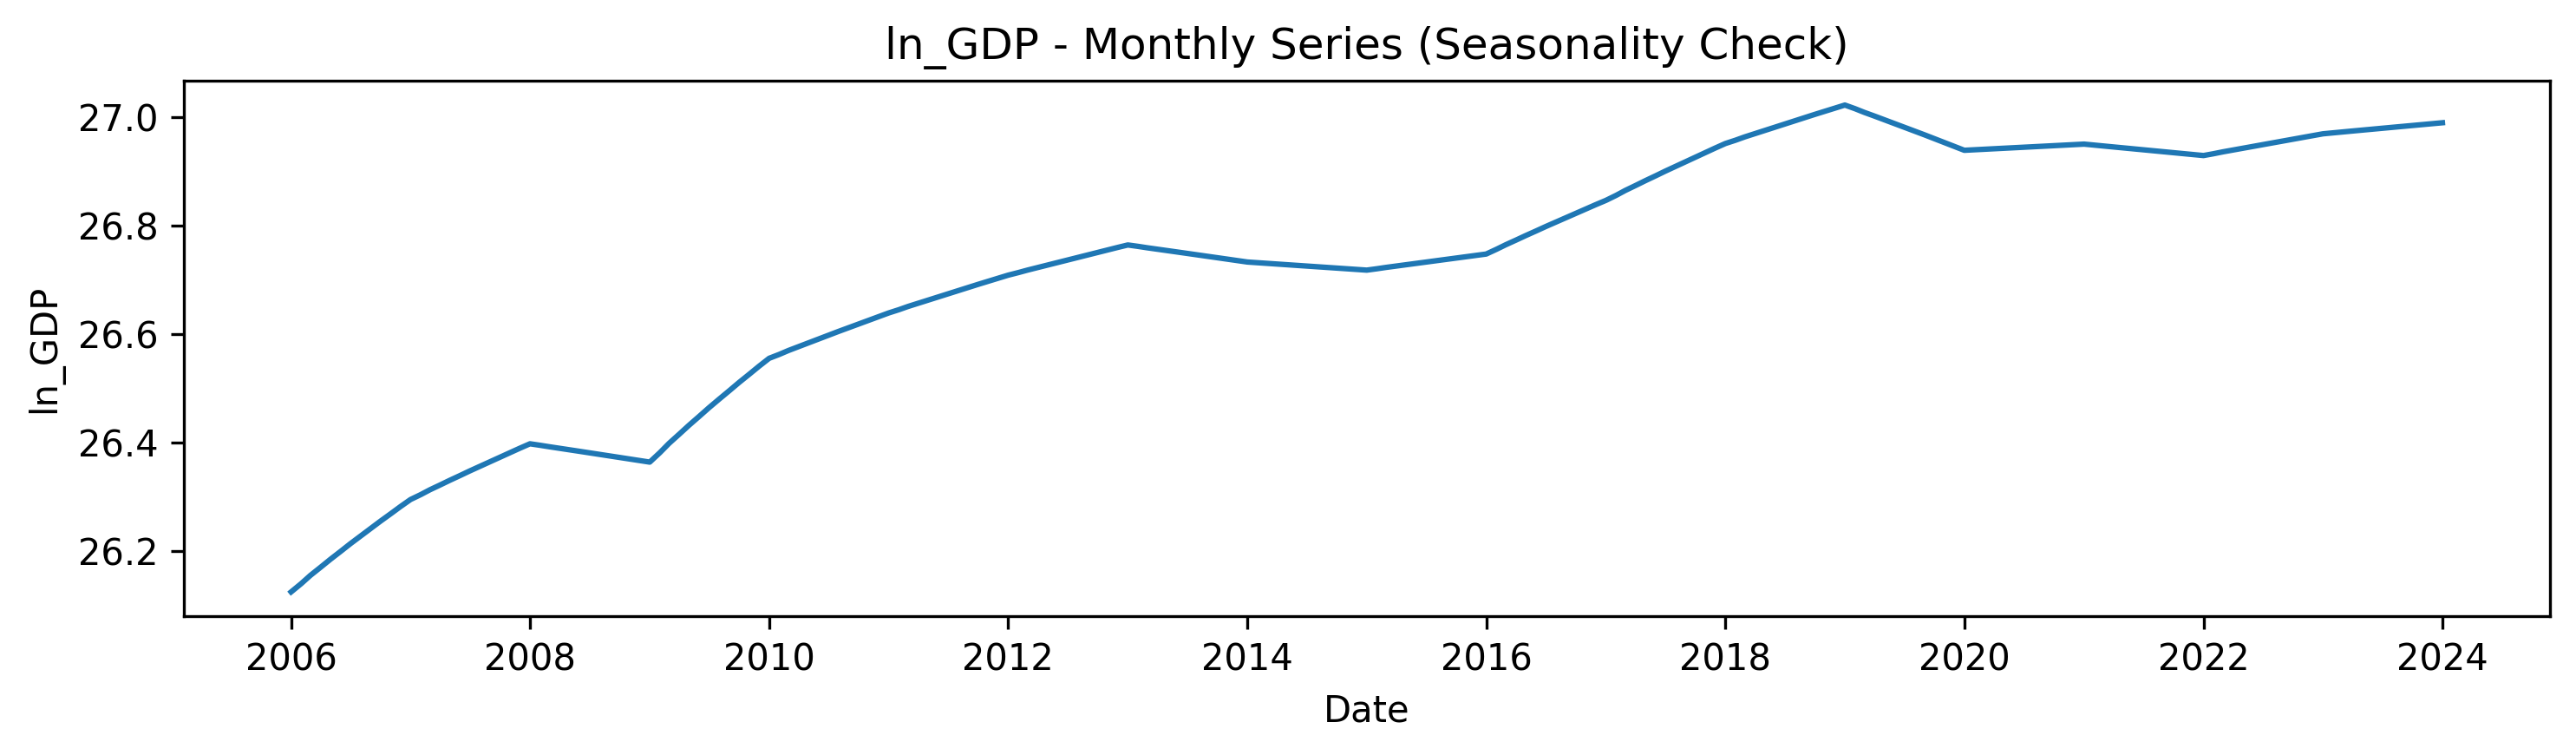

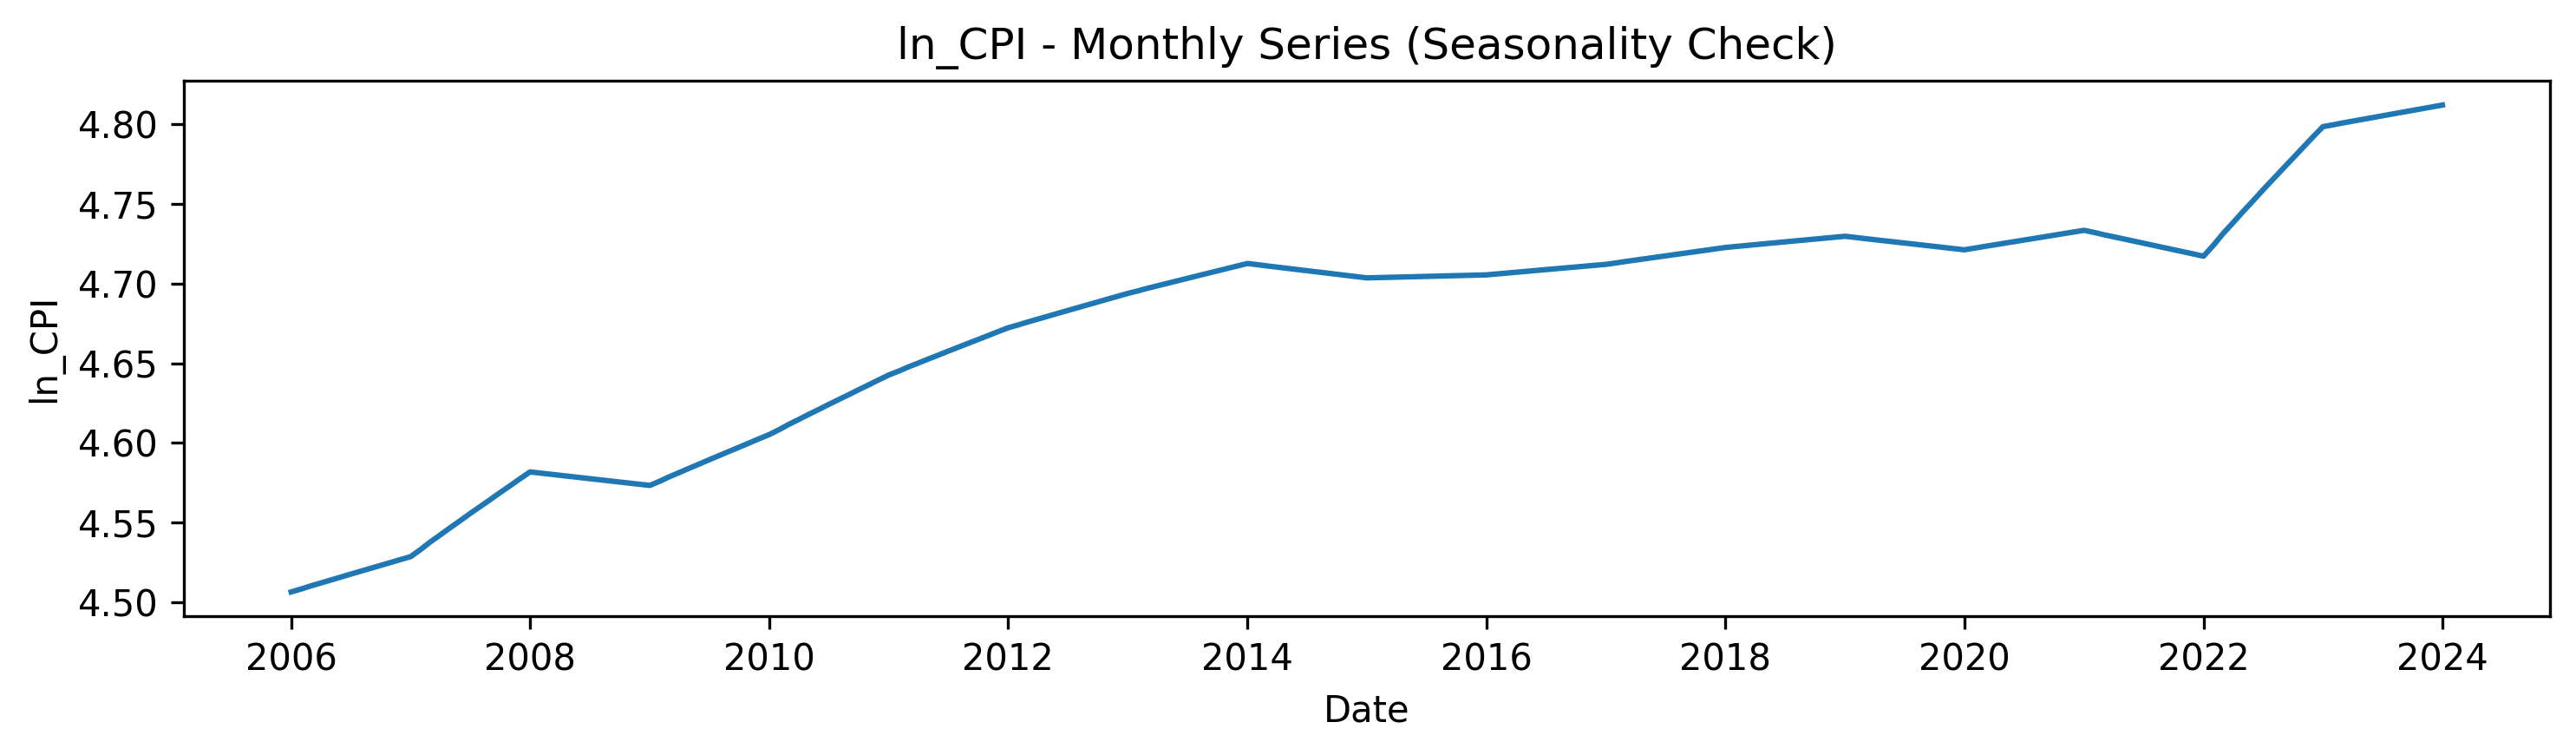

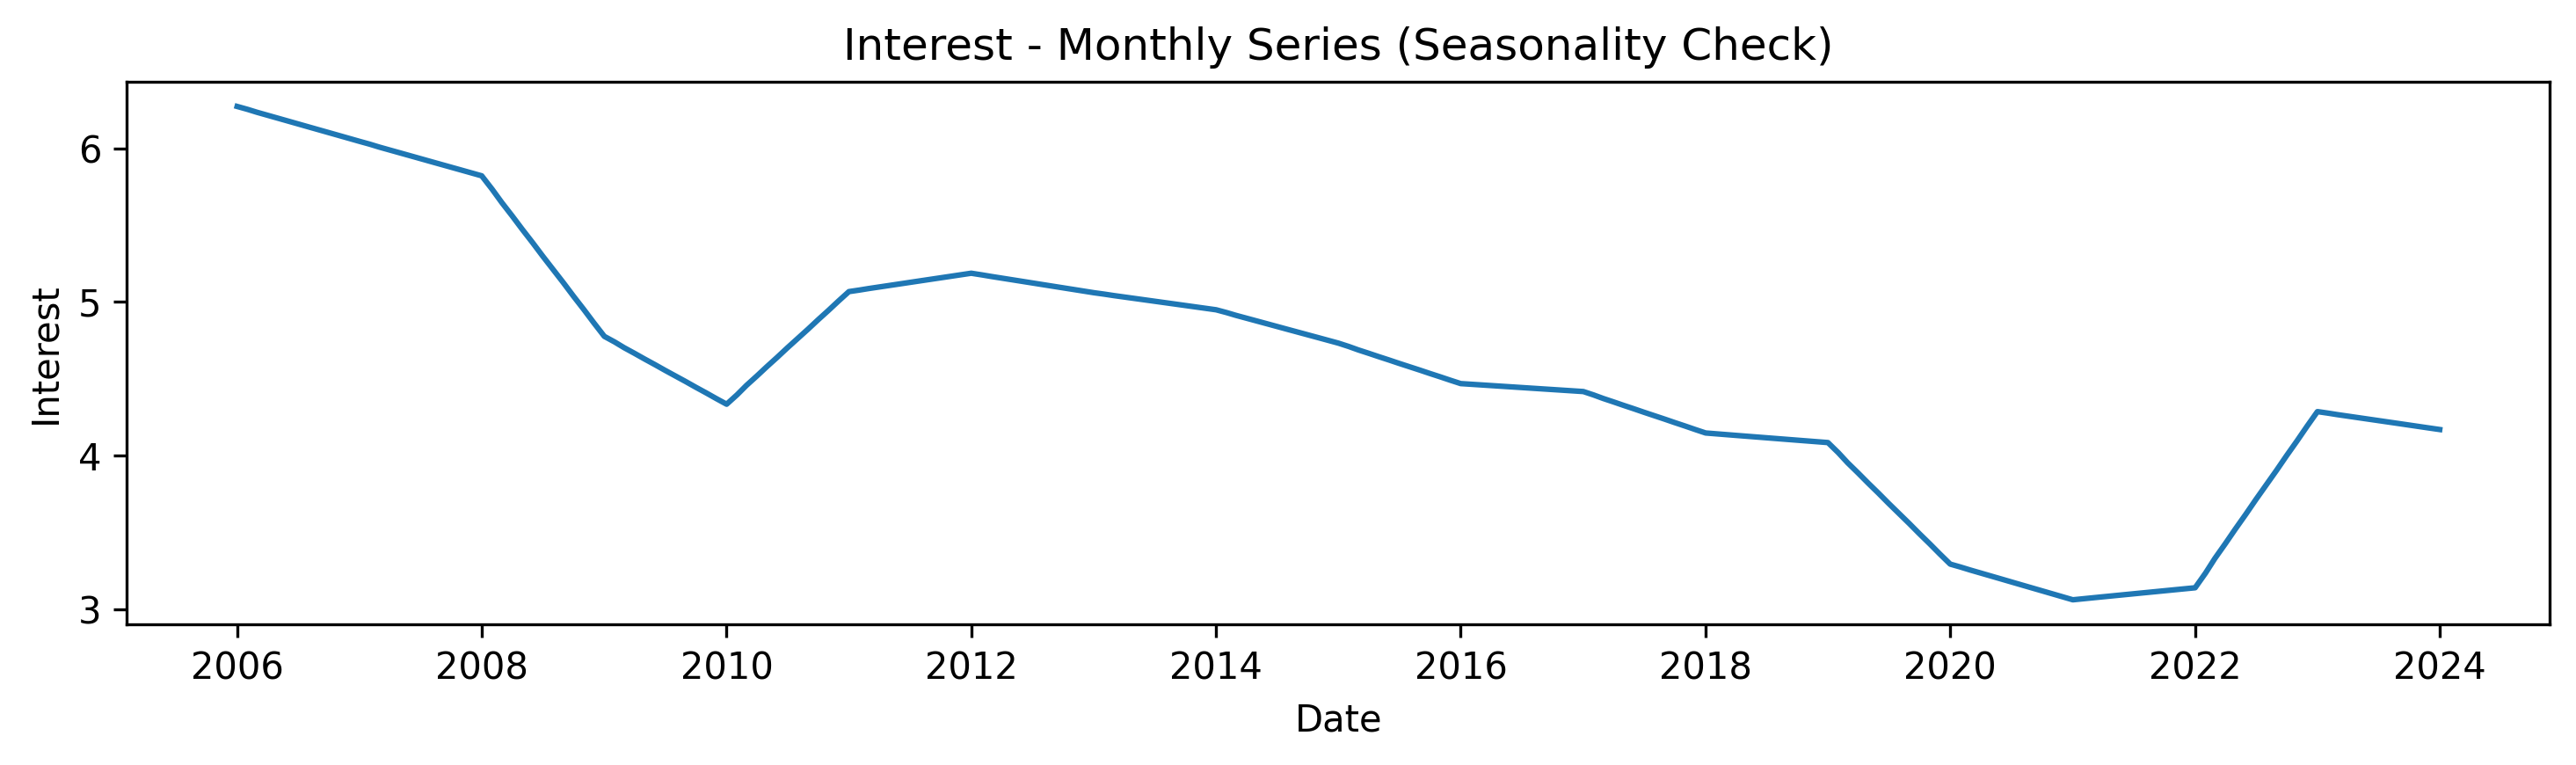

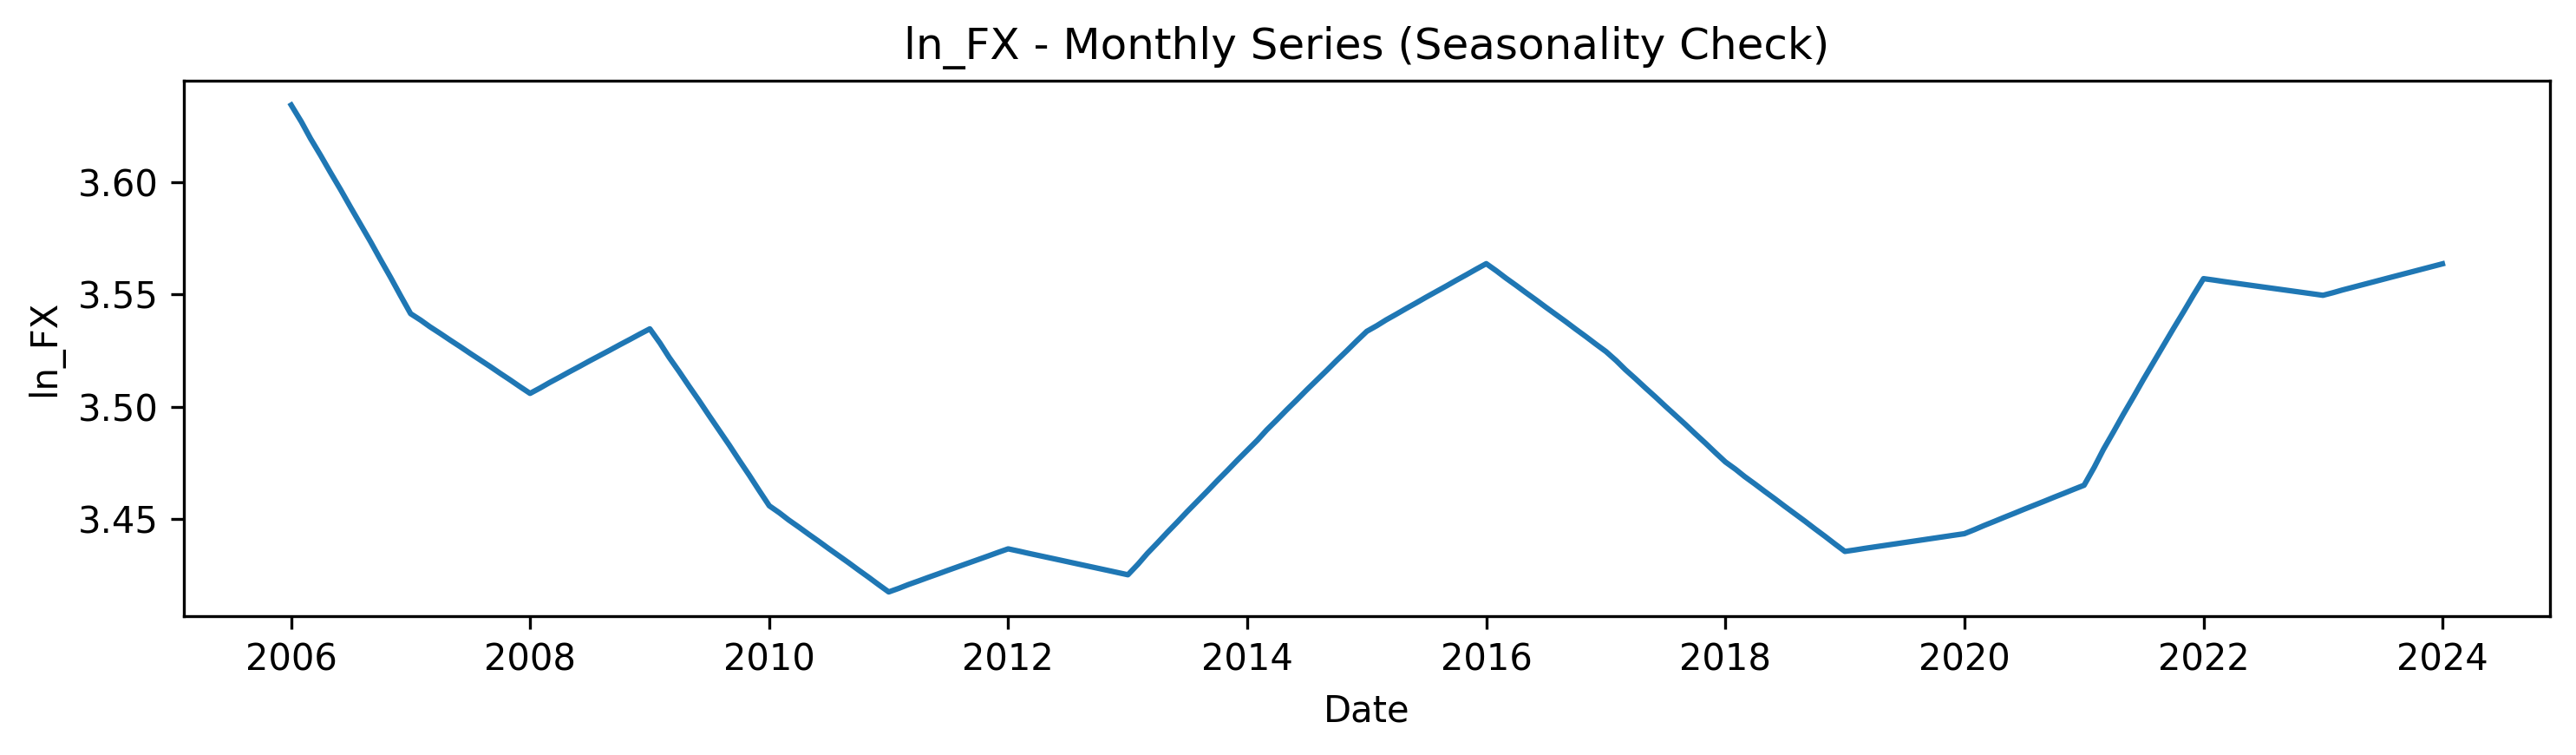

In [47]:
# 10.1 Plot monthly series by variable (seasonality focus)
for col in df.columns:
    plt.figure(figsize=(10, 3))
    plt.plot(df.index, df[col], label=col)
    plt.title(f'{col} - Monthly Series (Seasonality Check)')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### 10.2 ACF-based seasonality check

We plot the autocorrelation function (ACF) up to 24 lags for each variable. Strong spikes at lag 12 may suggest annual seasonality in monthly data. This does not prove seasonality by itself, but it is useful evidence.

<Figure size 2400x900 with 0 Axes>

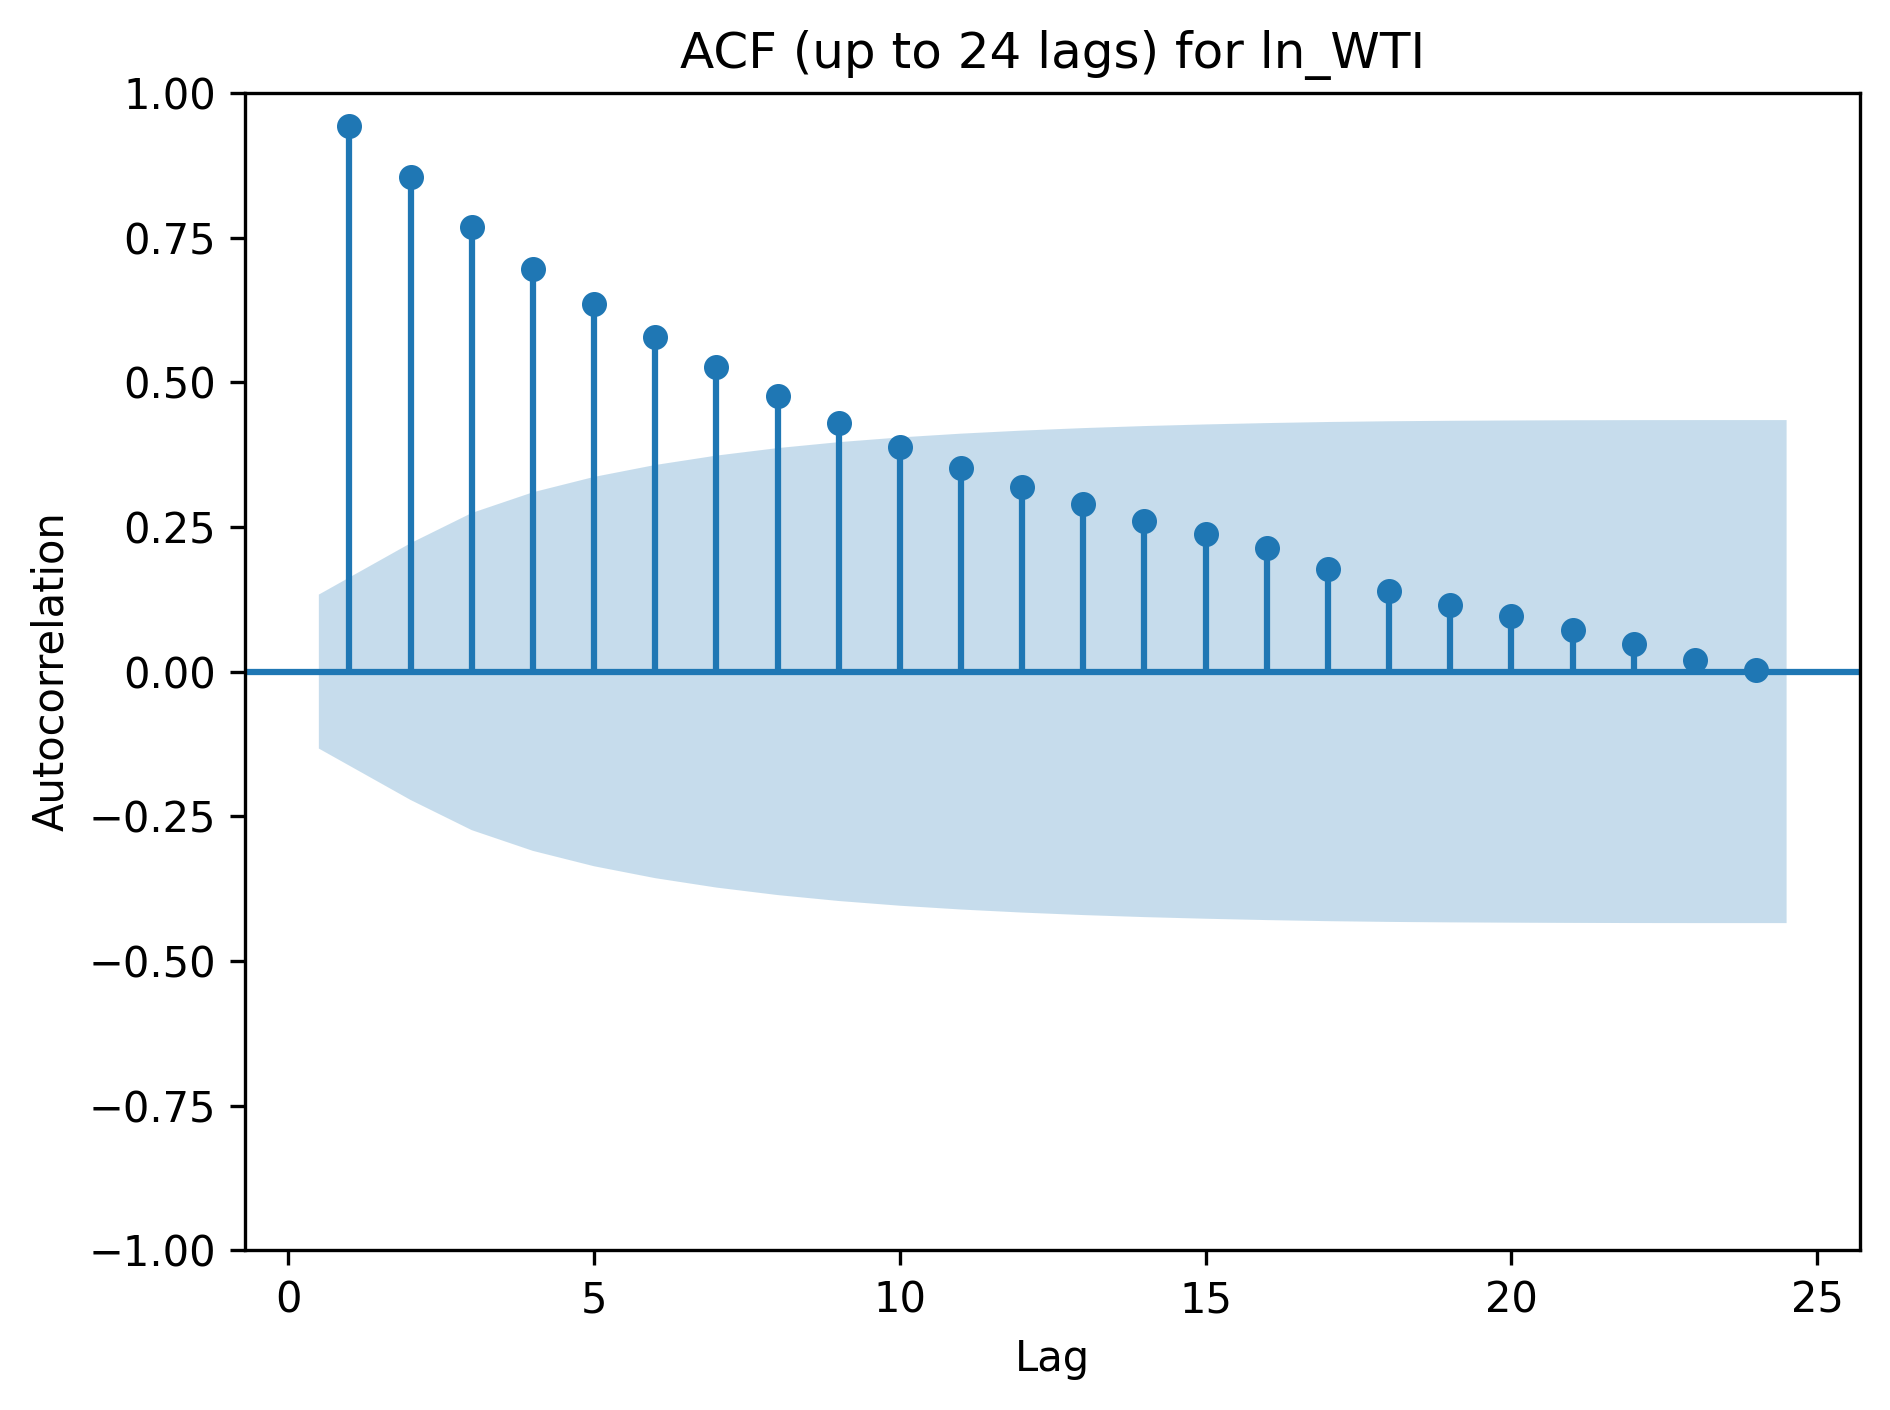

Note: Check for spike at lag 12 for ln_WTI.


<Figure size 2400x900 with 0 Axes>

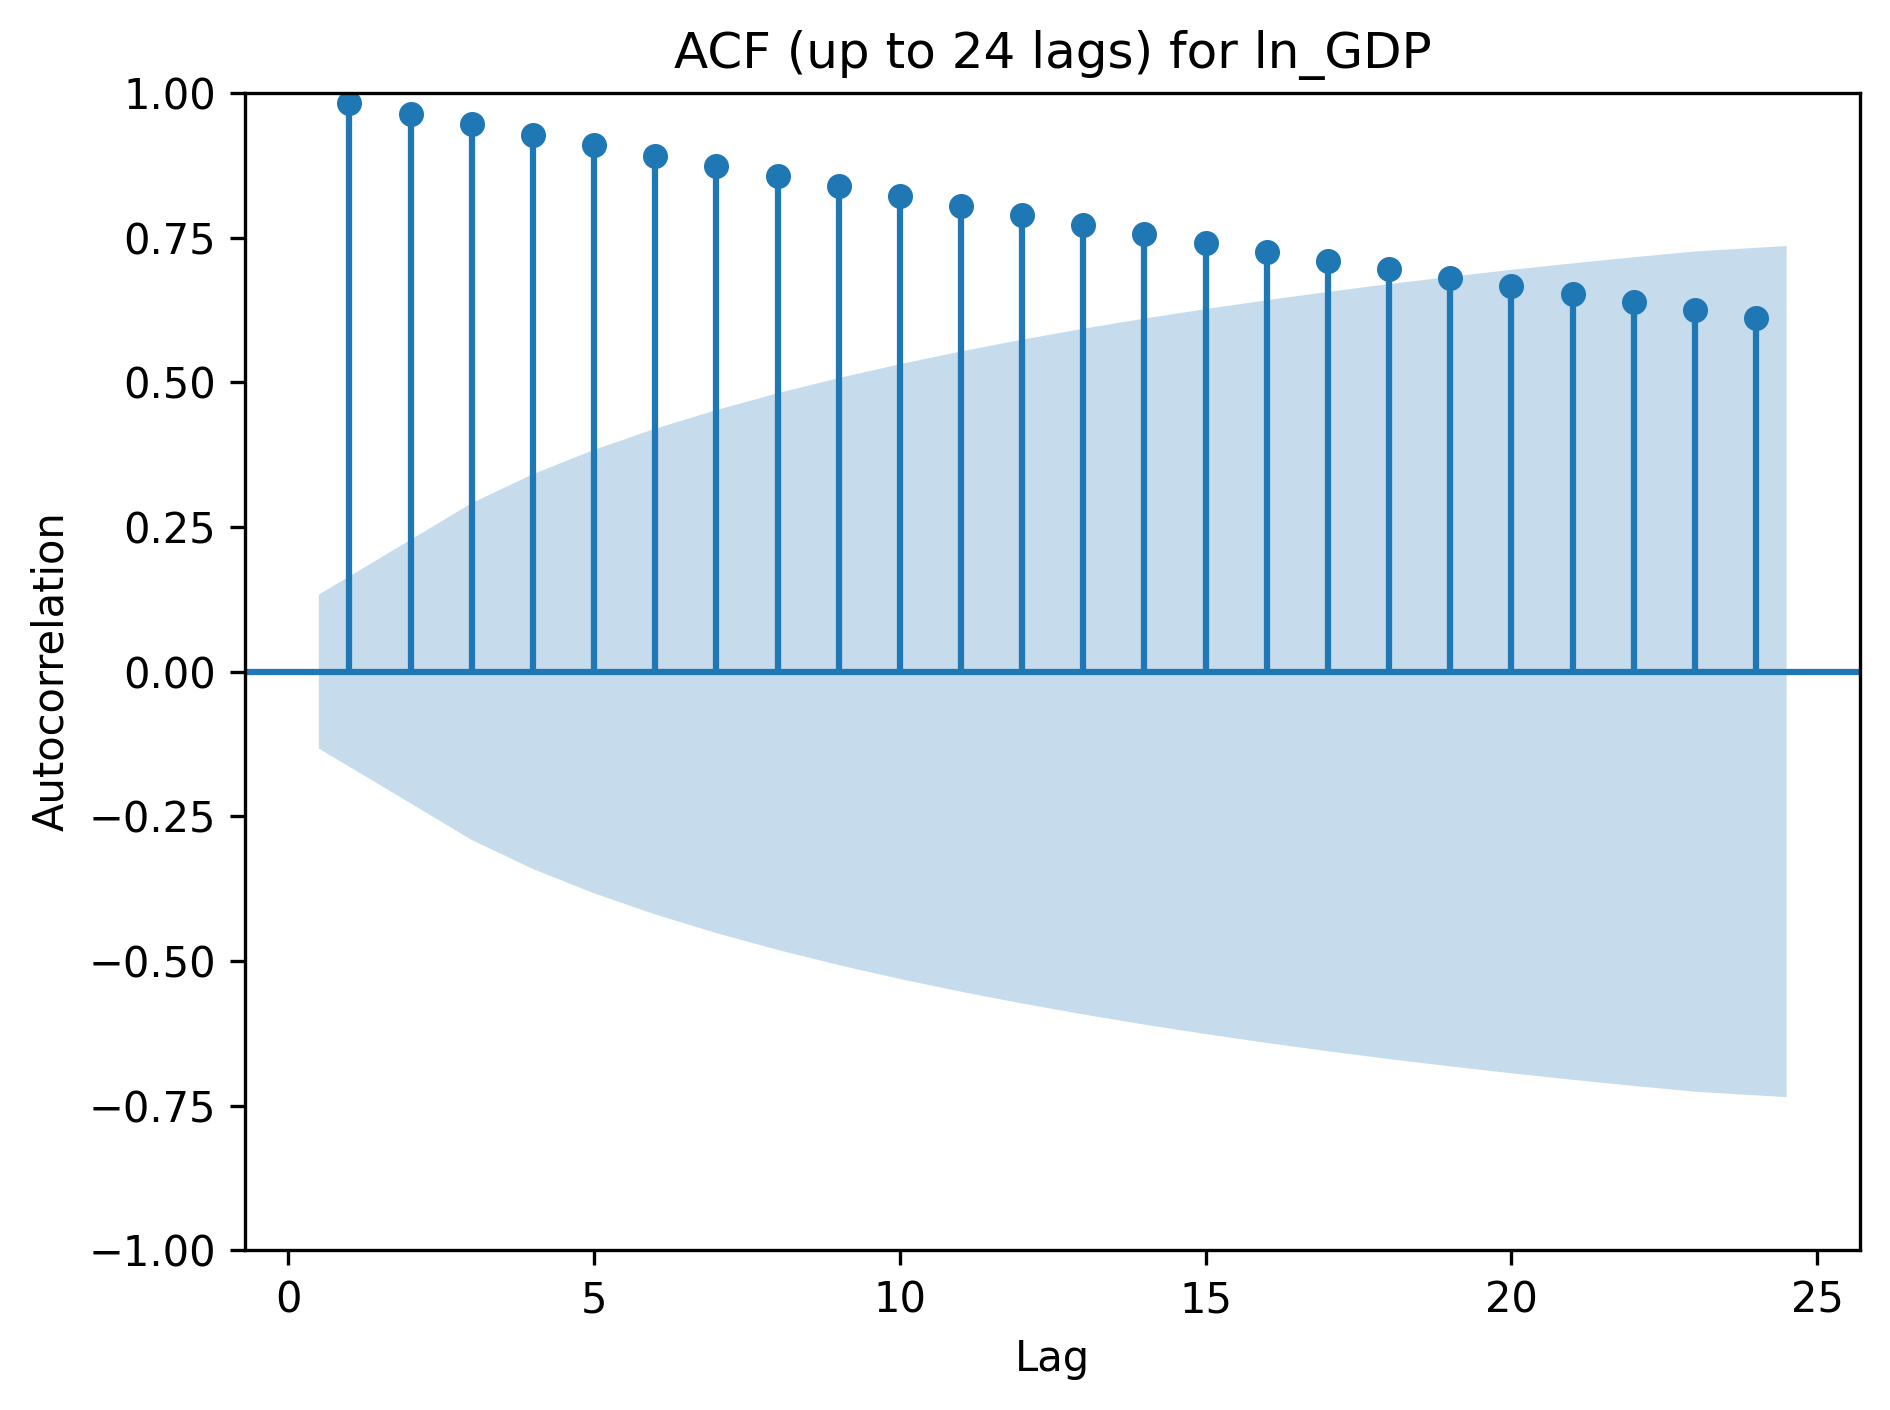

Note: Check for spike at lag 12 for ln_GDP.


<Figure size 2400x900 with 0 Axes>

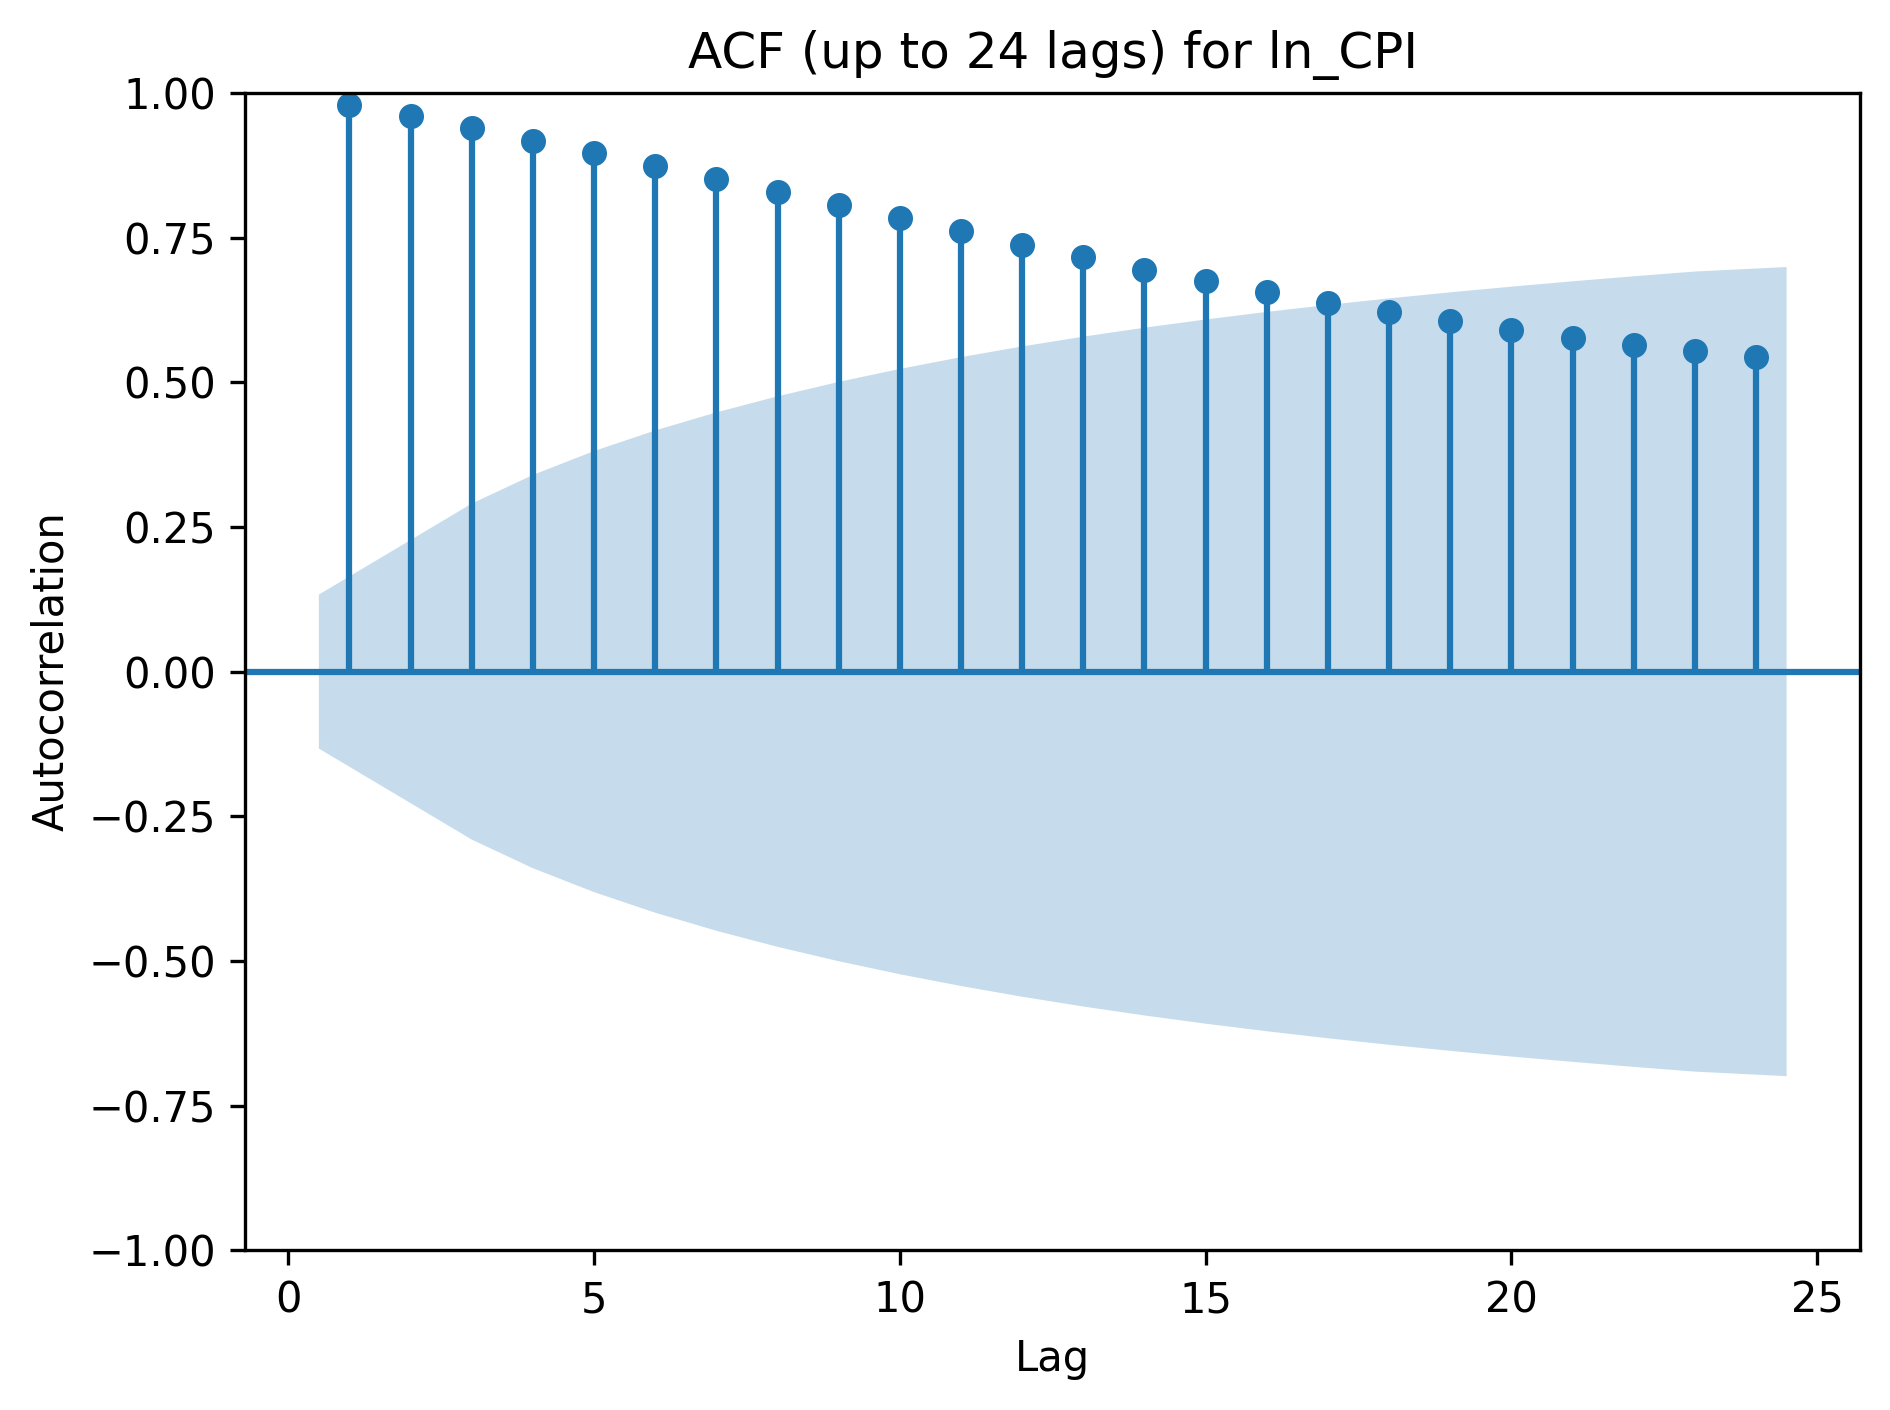

Note: Check for spike at lag 12 for ln_CPI.


<Figure size 2400x900 with 0 Axes>

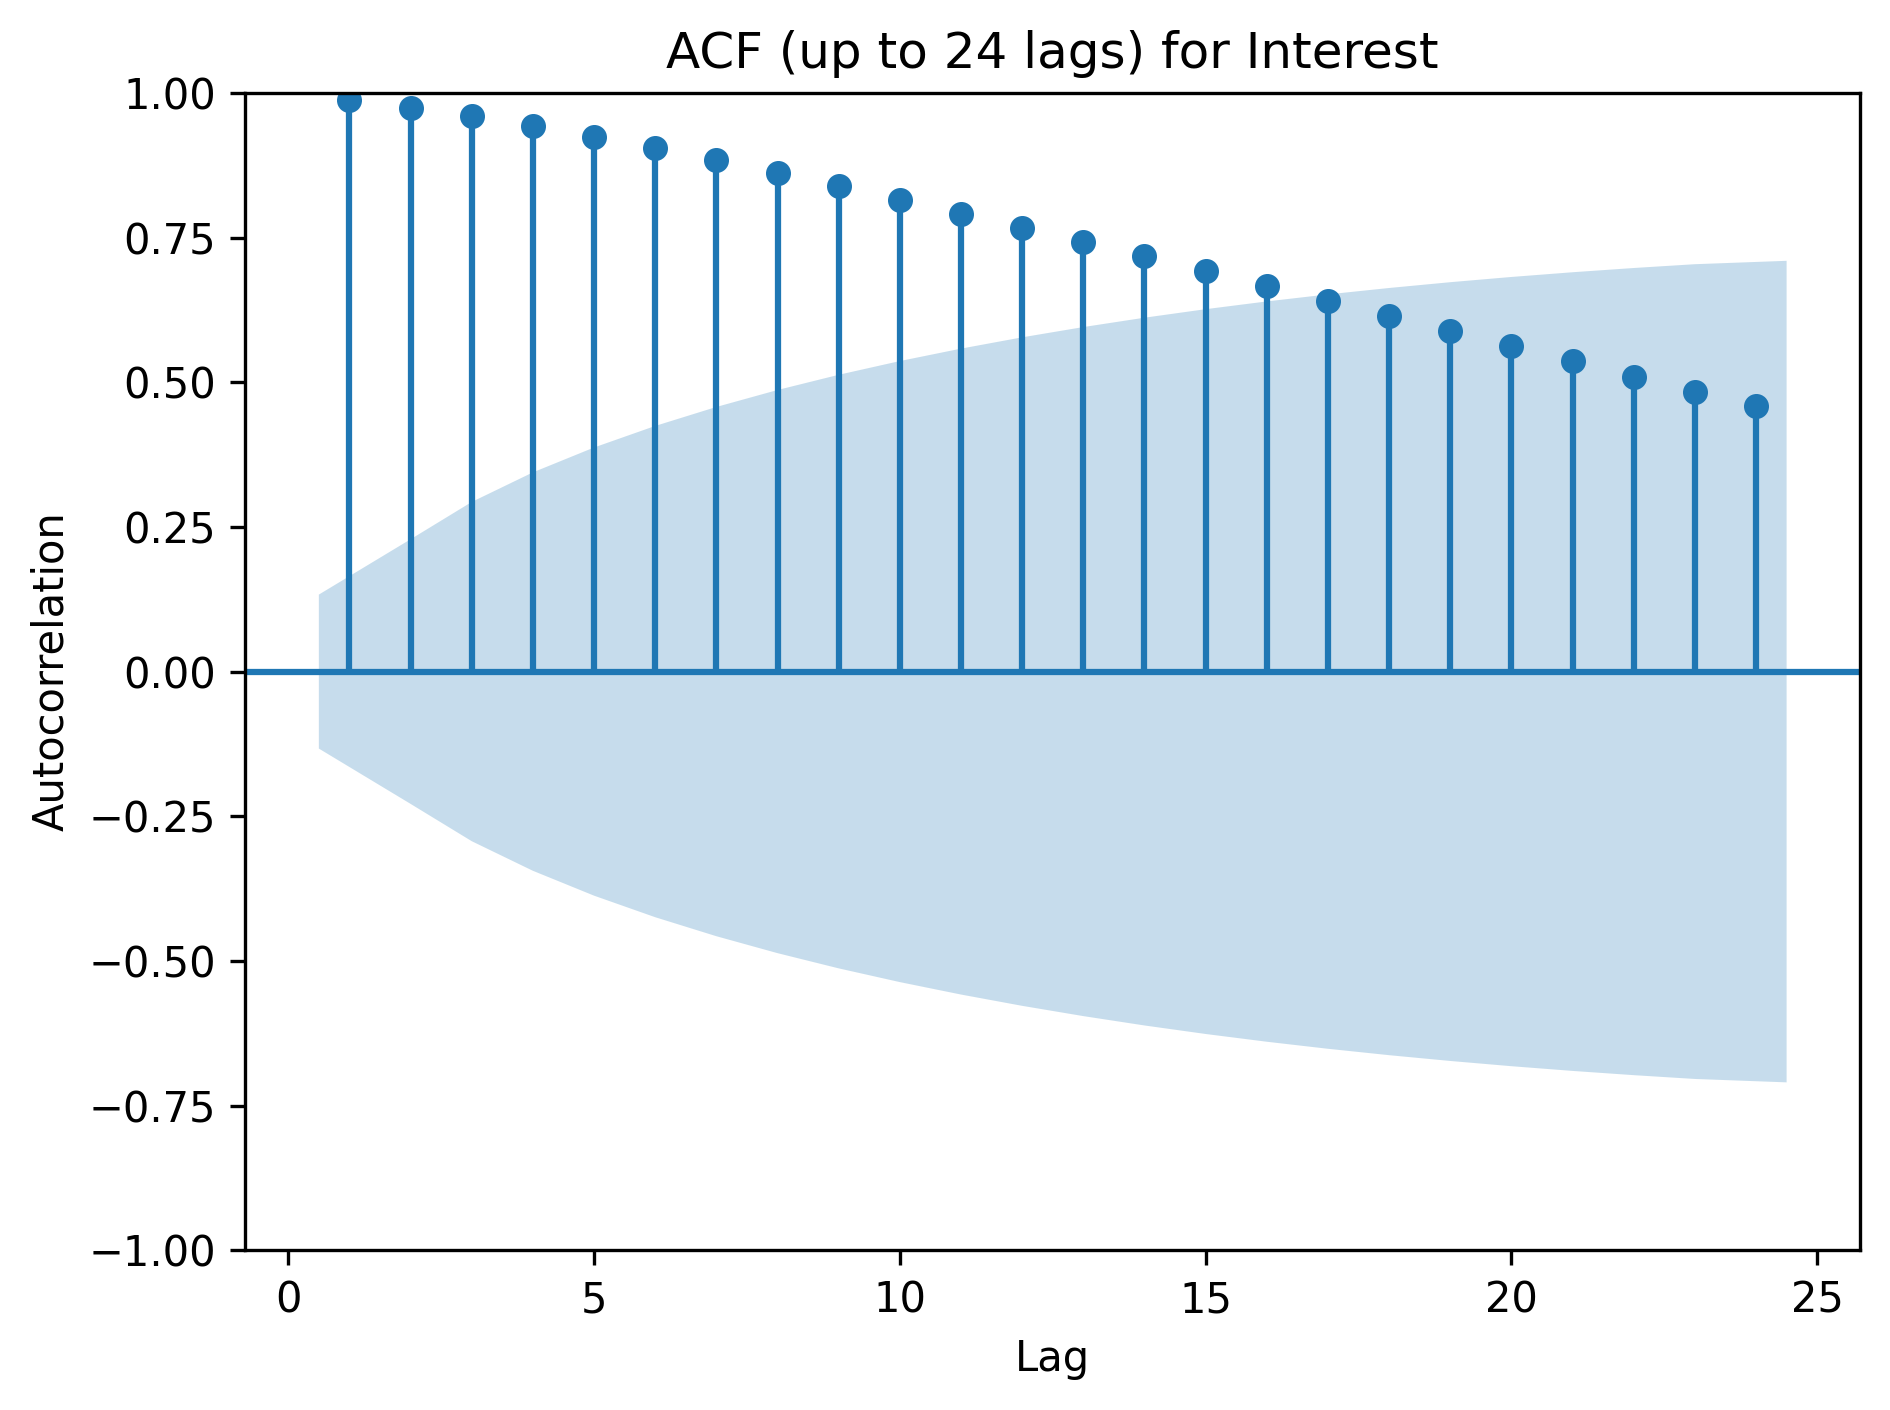

Note: Check for spike at lag 12 for Interest.


<Figure size 2400x900 with 0 Axes>

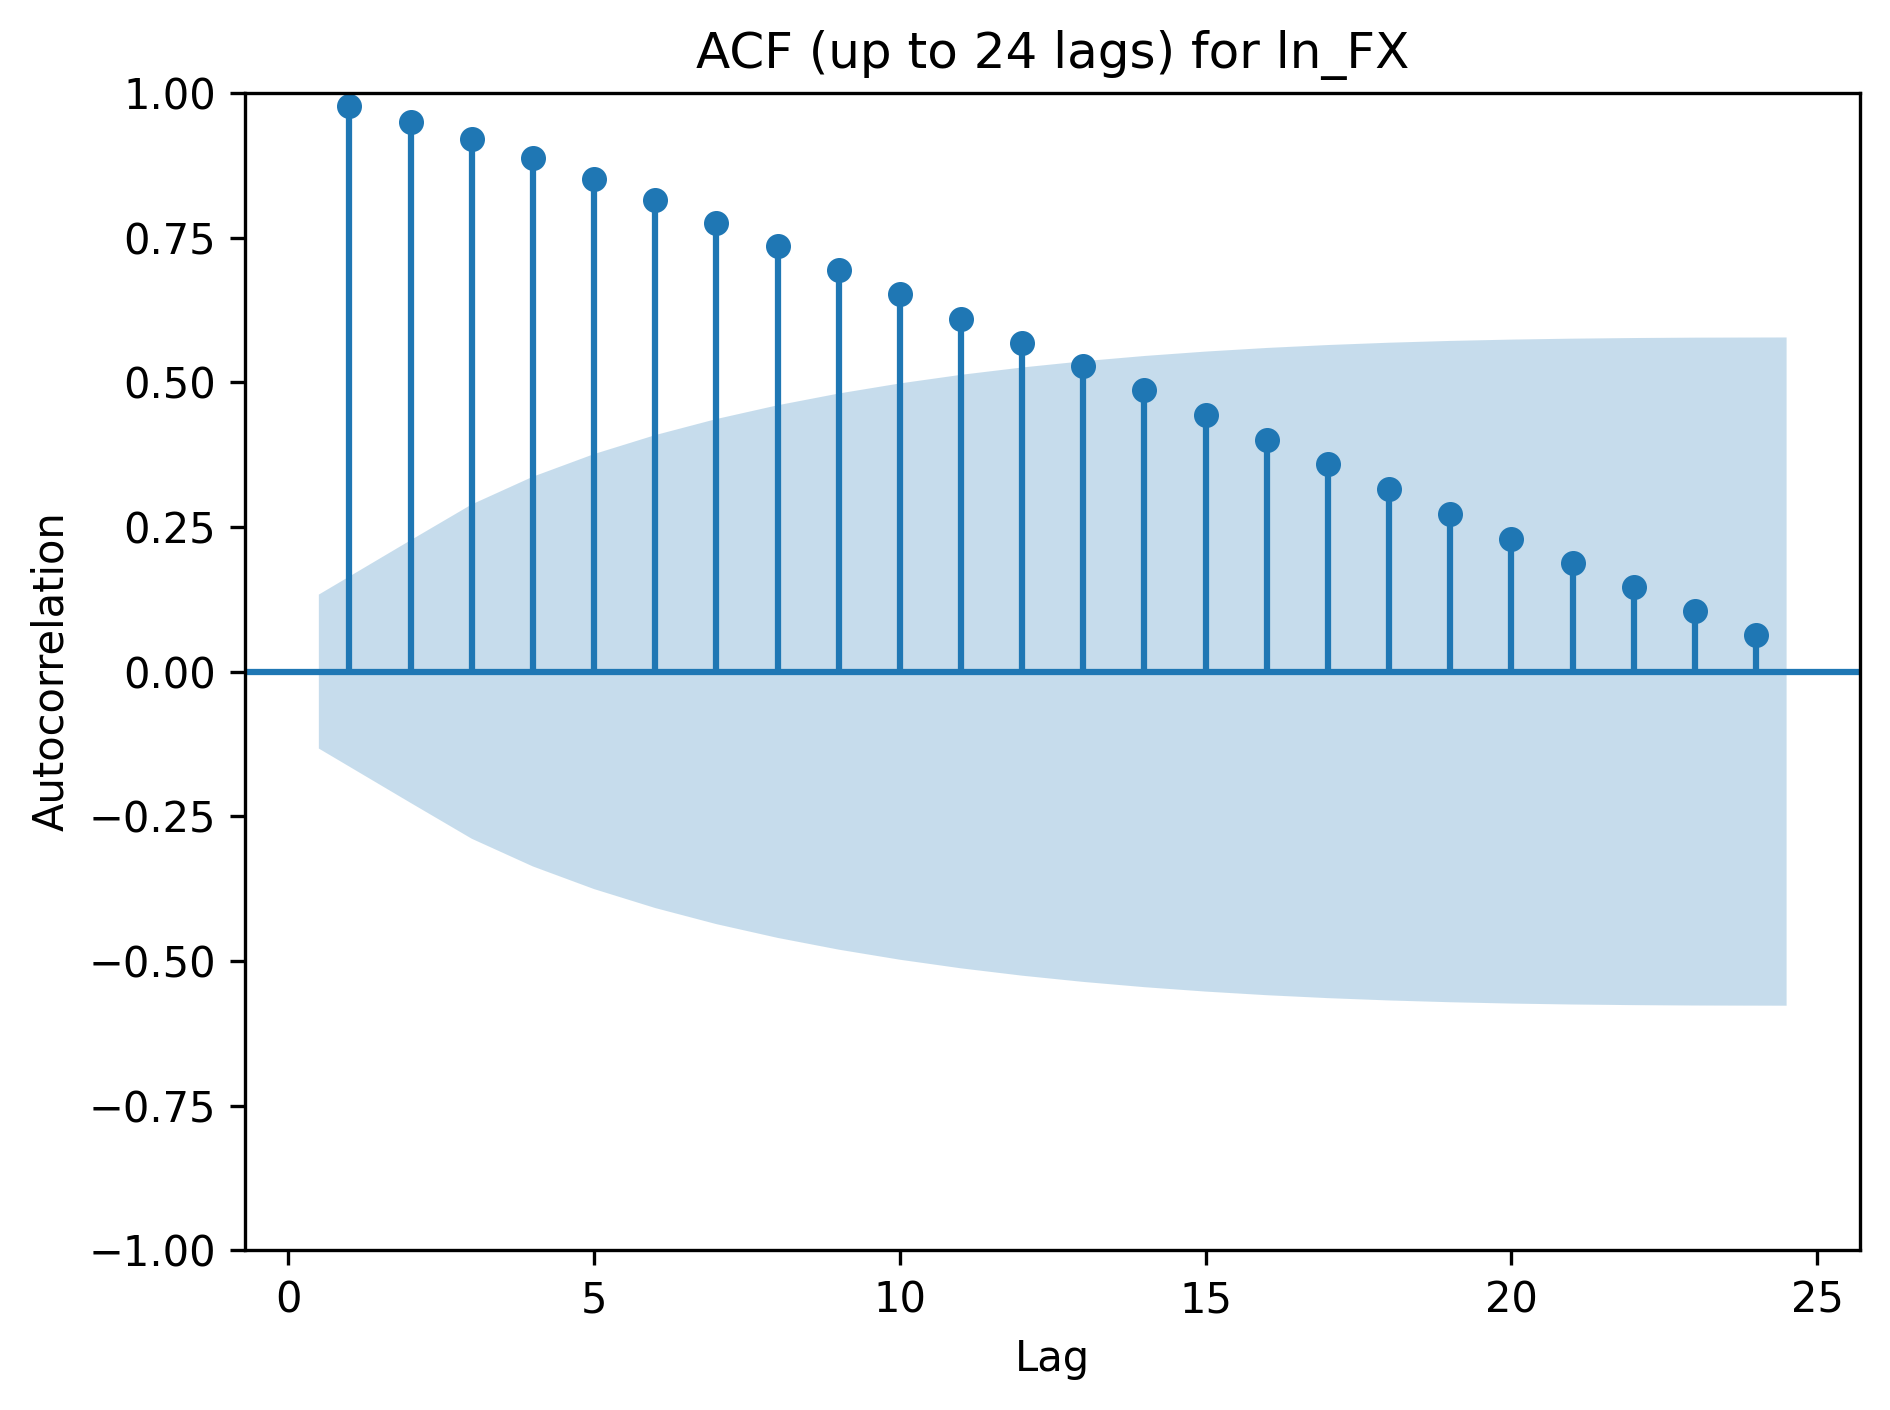

Note: Check for spike at lag 12 for ln_FX.


In [48]:
# 10.2 ACF-based seasonality check
from statsmodels.graphics.tsaplots import plot_acf

for col in df.columns:
    plt.figure(figsize=(8, 3))
    plot_acf(df[col].dropna(), lags=24, zero=False)
    plt.title(f'ACF (up to 24 lags) for {col}')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.tight_layout()
    plt.show()
    # Simple visual note
    print(f'Note: Check for spike at lag 12 for {col}.')

## 11. Seasonal Differencing

Seasonal differencing at lag 12 is a common approach for monthly data. The transformed series is $Y_t - Y_{t-12}$, which removes recurring yearly seasonal structure.

In [49]:
# 11. Seasonal differencing (lag 12)
df_seasonal_diff = df.diff(12).dropna()
print('Shape after seasonal differencing:', df_seasonal_diff.shape)
print('Head:')
print(df_seasonal_diff.head())
print('Missing values after seasonal differencing:\n', df_seasonal_diff.isnull().sum())

Shape after seasonal differencing: (205, 5)
Head:
              ln_WTI   ln_GDP   ln_CPI  Interest     ln_FX
date                                                      
2007-01-01 -0.183507 0.170348 0.022168 -0.227239 -0.092989
2007-02-01 -0.038912 0.163963 0.024848 -0.227026 -0.088475
2007-03-01 -0.036444 0.157731 0.027512 -0.226812 -0.083914
2007-04-01 -0.081992 0.151645 0.030158 -0.226599 -0.079305
2007-05-01 -0.110158 0.145702 0.032788 -0.226386 -0.074647
Missing values after seasonal differencing:
 ln_WTI      0
ln_GDP      0
ln_CPI      0
Interest    0
ln_FX       0
dtype: int64


## 12. Stationarity After Seasonal Differencing

We now run ADF, KPSS, and PP tests on the seasonally differenced data. The same helper functions as above are reused. Stationarity is defined as ADF p < 0.05 and KPSS p > 0.05.

In [50]:
# 12. Stationarity tests after seasonal differencing
seasonal_diff_results = []
for col in df_seasonal_diff.columns:
    adf = perform_adf_test(df_seasonal_diff[col], col, regression='c')
    kpss = perform_kpss_test(df_seasonal_diff[col], regression='c')
    try:
        pp = perform_pp_test(df_seasonal_diff[col], col, regression='c')
    except:
        pp = None
    adf_p = adf['P-Value'] if adf else np.nan
    kpss_p = kpss['P-Value'] if kpss else np.nan
    pp_p = pp['P-Value'] if pp else np.nan
    stationary = (adf_p < 0.05) and (kpss_p > 0.05)
    if stationary:
        reason = 'Stationary after seasonal differencing'
    else:
        reason = 'Still non-stationary after seasonal differencing'
    seasonal_diff_results.append({
        'Variable': col,
        'ADF_SeasonalDiff_p': adf_p,
        'KPSS_SeasonalDiff_p': kpss_p,
        'PP_SeasonalDiff_p': pp_p,
        'SeasonalDiff_Stationary': stationary,
        'Reason': reason
    })
seasonal_diff_summary = pd.DataFrame(seasonal_diff_results)
print(seasonal_diff_summary)

KPSS test failed: 'dict' object is not callable
KPSS test failed: 'NoneType' object is not callable
KPSS test failed: 'NoneType' object is not callable
KPSS test failed: 'NoneType' object is not callable
   Variable  ADF_SeasonalDiff_p  KPSS_SeasonalDiff_p  PP_SeasonalDiff_p  \
0    ln_WTI            0.015386             0.100000           0.019140   
1    ln_GDP            0.059602                  NaN           0.063836   
2    ln_CPI            0.259460                  NaN           0.109300   
3  Interest            0.007154                  NaN           0.130500   
4     ln_FX            0.057302                  NaN           0.070251   

   SeasonalDiff_Stationary                                            Reason  
0                     True            Stationary after seasonal differencing  
1                    False  Still non-stationary after seasonal differencing  
2                    False  Still non-stationary after seasonal differencing  
3                    False  S

## 13. Additional Check: Seasonal and First Differencing

If seasonal differencing alone does not resolve non-stationarity, it is useful to test the combination: first difference + seasonal difference.

In [51]:
# 13. Combined first + seasonal differencing
df_diff1_seasonal = df.diff().diff(12).dropna()
diff1_seasonal_results = []
for col in df_diff1_seasonal.columns:
    adf = perform_adf_test(df_diff1_seasonal[col], col, regression='c')
    kpss = perform_kpss_test(df_diff1_seasonal[col], regression='c')
    try:
        pp = perform_pp_test(df_diff1_seasonal[col], col, regression='c')
    except:
        pp = None
    adf_p = adf['P-Value'] if adf else np.nan
    kpss_p = kpss['P-Value'] if kpss else np.nan
    pp_p = pp['P-Value'] if pp else np.nan
    stationary = (adf_p < 0.05) and (kpss_p > 0.05)
    if stationary:
        reason = 'Stationary after first + seasonal differencing'
    else:
        reason = 'Still non-stationary after first + seasonal differencing'
    diff1_seasonal_results.append({
        'Variable': col,
        'ADF_Diff1Seasonal_p': adf_p,
        'KPSS_Diff1Seasonal_p': kpss_p,
        'PP_Diff1Seasonal_p': pp_p,
        'Diff1Seasonal_Stationary': stationary,
        'Reason': reason
    })
diff1_seasonal_summary = pd.DataFrame(diff1_seasonal_results)
print(diff1_seasonal_summary)

KPSS test failed: 'NoneType' object is not callable
KPSS test failed: 'NoneType' object is not callable
KPSS test failed: 'NoneType' object is not callable
KPSS test failed: 'NoneType' object is not callable
KPSS test failed: 'NoneType' object is not callable
   Variable  ADF_Diff1Seasonal_p  KPSS_Diff1Seasonal_p  PP_Diff1Seasonal_p  \
0    ln_WTI             0.000001                   NaN            0.000000   
1    ln_GDP             0.027788                   NaN            0.006277   
2    ln_CPI             0.126524                   NaN            0.007083   
3  Interest             0.033322                   NaN            0.022787   
4     ln_FX             0.057400                   NaN            0.009487   

   Diff1Seasonal_Stationary                                             Reason  
0                     False  Still non-stationary after first + seasonal di...  
1                     False  Still non-stationary after first + seasonal di...  
2                     False 

## 14. Comparison of Stationarity Outcomes

The table below summarizes, for each variable: the original monthly classification, stationarity after seasonal differencing, after first + seasonal differencing, and an interpretation note.

In [52]:
# 14. Comparison table
comparison_rows = []
for col in df.columns:
    orig_order = summary_df[summary_df['Variable'] == col]['Order'].values[0] if col in summary_df['Variable'].values else 'N/A'
    seas_stat = seasonal_diff_summary[seasonal_diff_summary['Variable'] == col]['SeasonalDiff_Stationary'].values[0]
    diff1_seas_stat = diff1_seasonal_summary[diff1_seasonal_summary['Variable'] == col]['Diff1Seasonal_Stationary'].values[0]
    # Interpretation labels aligned with final results
    if orig_order == 'I(0)':
        interp = 'Already stationary at level (I(0))'
    elif seas_stat or diff1_seas_stat:
        interp = 'Some improvement, but not sufficient for the monthly specification'
    else:
        interp = 'No meaningful improvement from seasonal adjustment; monthly specification remains unsuitable'
    comparison_rows.append({
        'Variable': col,
        'Original_Order': orig_order,
        'SeasonalDiff_Stationary': seas_stat,
        'Diff1Seasonal_Stationary': diff1_seas_stat,
        'Interpretation': interp
    })
seasonality_comparison = pd.DataFrame(comparison_rows)
print(seasonality_comparison)

   Variable Original_Order  SeasonalDiff_Stationary  Diff1Seasonal_Stationary  \
0    ln_WTI           I(0)                     True                     False   
1    ln_GDP           I(2)                    False                     False   
2    ln_CPI           I(2)                    False                     False   
3  Interest           I(2)                    False                     False   
4     ln_FX           I(2)                    False                     False   

                                      Interpretation  
0                 Already stationary at level (I(0))  
1  No meaningful improvement from seasonal adjust...  
2  No meaningful improvement from seasonal adjust...  
3  No meaningful improvement from seasonal adjust...  
4  No meaningful improvement from seasonal adjust...  


### 14.1 Final Comparison Table (Readable Format)

This table provides an easier final view with check/cross indicators for seasonal differencing outcomes.

In [53]:
# 14.1 Final comparison table (readable format)

def decide_final_transform(row):
    orig = row['Original_Order']
    d12_ok = row['SeasonalDiff_Stationary']
    d1d12_ok = row['Diff1Seasonal_Stationary']

    if orig == 'I(0)':
        return 'Keep level (I(0))'
    if d12_ok:
        return 'Seasonal (Diff12)'
    if d1d12_ok:
        return 'Seasonal + trend (Diff1+Diff12)'
    return 'Unresolved (consider quarterly or re-specification)'

final_comparison_table = seasonality_comparison.copy()
final_comparison_table['Diff12'] = final_comparison_table['SeasonalDiff_Stationary'].map({True: '✅', False: '❌'})
final_comparison_table['Diff1+Diff12'] = final_comparison_table['Diff1Seasonal_Stationary'].map({True: '✅', False: '❌'})
final_comparison_table['Final Decision'] = final_comparison_table.apply(decide_final_transform, axis=1)

final_comparison_table = final_comparison_table[
    ['Variable', 'Original_Order', 'Diff12', 'Diff1+Diff12', 'Final Decision']
].rename(columns={'Original_Order': 'Original'})

print('FINAL COMPARISON TABLE')
print(final_comparison_table)

# Optional: save for reporting
final_comparison_table.to_csv('../../outputs/THA/final_comparison_table_tha.csv', index=False)
print('Saved: ../../outputs/THA/final_comparison_table_tha.csv')

FINAL COMPARISON TABLE
   Variable Original Diff12 Diff1+Diff12  \
0    ln_WTI     I(0)      ✅            ❌   
1    ln_GDP     I(2)      ❌            ❌   
2    ln_CPI     I(2)      ❌            ❌   
3  Interest     I(2)      ❌            ❌   
4     ln_FX     I(2)      ❌            ❌   

                                      Final Decision  
0                                  Keep level (I(0))  
1  Unresolved (consider quarterly or re-specifica...  
2  Unresolved (consider quarterly or re-specifica...  
3  Unresolved (consider quarterly or re-specifica...  
4  Unresolved (consider quarterly or re-specifica...  
Saved: ../../outputs/THA/final_comparison_table_tha.csv


## 15. Interpretation After Seasonality Check

Seasonal adjustment does not materially improve stationarity for most macro variables in the monthly dataset. Beyond `ln_WTI` (already I(0) at level), `ln_GDP`, `ln_CPI`, `Interest`, and `ln_FX` remain unresolved / I(2)-type under the current monthly specification.

This pattern indicates that the apparent higher-order non-stationarity is unlikely to be driven mainly by seasonality. A more plausible explanation is the persistence, smooth construction, or frequency mismatch of the monthly macroeconomic series.

Accordingly, the monthly specification remains unsuitable for final structural modeling.

In [54]:
# 15. Print summary counts and interpretation
n_vars = len(df.columns)
n_seasonal_stationary = seasonal_diff_summary['SeasonalDiff_Stationary'].sum()
n_diff1_seasonal_stationary = diff1_seasonal_summary['Diff1Seasonal_Stationary'].sum()
n_unresolved = n_vars - (n_seasonal_stationary + n_diff1_seasonal_stationary)
print(f'Variables stationary after seasonal differencing: {n_seasonal_stationary}/{n_vars}')
print(f'Variables stationary only after first + seasonal differencing: {n_diff1_seasonal_stationary}/{n_vars}')
print(f'Variables still unresolved: {n_unresolved}/{n_vars}')

Variables stationary after seasonal differencing: 1/5
Variables stationary only after first + seasonal differencing: 0/5
Variables still unresolved: 4/5


## Final Conclusion

Under the current monthly specification, `ln_WTI` can be classified as I(0). In contrast, `ln_GDP`, `ln_CPI`, `Interest`, and `ln_FX` continue to exhibit unresolved or I(2)-type behavior, even after seasonal adjustment checks.

Neither seasonal differencing alone nor the combination of first and seasonal differencing is sufficient to establish stationarity for most of these macro variables. This suggests that the apparent higher-order non-stationarity in the monthly data is unlikely to be driven primarily by seasonality. Instead, it more likely reflects the persistence, smooth construction, or frequency mismatch of the monthly macroeconomic series.

Therefore, the current monthly dataset is not appropriate for final structural modeling. The recommended next step is to rebuild the Thailand dataset at quarterly frequency and repeat the stationarity analysis using the quarterly specification.

The next notebook will construct a quarterly Thailand dataset and repeat the stationarity analysis using the quarterly specification.

In [55]:
# 16. Save outputs
seasonal_diff_summary.to_csv('../../outputs/THA/seasonal_diff_summary_tha.csv', index=False)
diff1_seasonal_summary.to_csv('../../outputs/THA/diff1_seasonal_summary_tha.csv', index=False)
seasonality_comparison.to_csv('../../outputs/THA/seasonality_comparison_tha.csv', index=False)
print('Saved: ../../outputs/THA/seasonal_diff_summary_tha.csv')
print('Saved: ../../outputs/THA/diff1_seasonal_summary_tha.csv')
print('Saved: ../../outputs/THA/seasonality_comparison_tha.csv')

Saved: ../../outputs/THA/seasonal_diff_summary_tha.csv
Saved: ../../outputs/THA/diff1_seasonal_summary_tha.csv
Saved: ../../outputs/THA/seasonality_comparison_tha.csv
